# NBA Shot Quality: Shot-Make Modeling, Expected Points, and Pythagorean Standings

## Overview
This notebook trains multiple ML models to predict shot-make probability, aggregates **expected points** to team-games, and derives **Pythagorean expected wins** (exponent = 14).

**Data:** `enriched_data/nbastatsv3_2024_enriched_shots.csv`

---

## Latest Updates (December 2025)

### Models (13 total + voting ensemble)
| Category | Models |
|----------|--------|
| **Boosting (Optuna-tuned)** | LightGBM, HistGradientBoosting, GradientBoosting, XGBoost, CatBoost |
| **Ensemble** | RandomForest, ExtraTrees, AdaBoost |
| **Other** | LogisticRegression, MLP, GaussianNB, KNN |
| **Meta** | VotingEnsemble (soft voting over top 5 boosters) |

### Configuration
- `N_OPTUNA_TRIALS = 10` (Bayesian hyperparameter optimization)
- `PYTH_EXP = 14` (Pythagorean win formula exponent)
- `RANDOM_STATE = 42`
- TabNet disabled (often gets stuck, rarely outperforms boosting)

### Feature Engineering
- **Shot Clock × Location Interactions** (13 features):
  - `is_transition_paint`, `is_transition_midrange`, `is_transition_3pt`
  - `is_late_clock_paint`, `is_late_clock_midrange`, `is_desperation_3pt`
  - `is_heave_shot`, `is_rhythm_shot`
  - `clock_x_distance`, `clock_x_paint`, `clock_x_corner3`, `clock_x_above_break3`
  - `rhythm_x_distance`
- **Shot Type Features**: `is_paint`, `is_corner3`, `is_above_break3`, `is_midrange`
- **Text-Parsed Features**: `is_pullup`, `is_stepback`, `is_fadeaway`, `is_turnaround`, `is_driving`, `is_floating`, `is_cutting`, `is_tip`, `is_putback`, `is_second_chance`
- **Granular Shot Clock Buckets**: 0-4s, 4-8s, 8-12s, 12-16s, 16-20s, 20-24s

### Best Results (as of last run)
| Model | Test AUC | Notes |
|-------|----------|-------|
| voting_ensemble | **0.6674** | Soft voting over top 5 |
| lightgbm | 0.6673 | Best single model |
| hist_gb | 0.6664 | |
| gb | 0.6663 | |
| xgboost | 0.6661 | |

### Additional Analysis Cells
- **Stacking Ensemble**: LogisticRegressionCV meta-learner over top models
- **Separate 2PT/3PT Models**: Using LightGBM (2PT AUC: ~0.69, 3PT AUC: ~0.55)

---

## Pipeline
1. Load & inspect data
2. Feature engineering (shot clock interactions, text parsing)
3. Train/test split (80/20, stratified)
4. Train 13 models with Bayesian optimization (10 trials each for boosters)
5. Voting ensemble + stacking ensemble
6. Score all shots → expected points
7. Aggregate to team-game level
8. Compute Pythagorean expected wins
9. Compare expected vs actual standings

## Notes
- 3PT shots are inherently harder to predict (AUC ~0.55) due to lower variance
- Unified models outperform separate 2PT/3PT models for overall AUC
- Target of 70% AUC is challenging due to inherent randomness in shot outcomes


In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import os

# Bayesian optimization
try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.INFO)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna not available. Install with: pip install optuna")

N_OPTUNA_TRIALS = 10  # Reduced for faster iteration

# Try optional imports
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception as e:
    CATBOOST_AVAILABLE = False
    print("CatBoost not available. Install with: pip install catboost")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. Install with: pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available. Install with: pip install lightgbm")

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    TABNET_AVAILABLE = True
    import torch
except Exception as e:
    TABNET_AVAILABLE = False
    print("TabNet not available. Install with: pip install pytorch-tabnet")

# Paths
DATA_PATH = "enriched_data/nbastatsv3_2024_enriched_shots.csv"
MODELS_DIR = "models"
import os
import pickle
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
PYTH_EXP = 14  # Pythagorean exponent for NBA win probability


## 1) Load & inspect data

In [9]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Put the CSV in the working directory or update DATA_PATH.")

df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}")
df.head()


Rows: 219,528


,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,...,videoAvailable,shotValue,actionId,gameId,ABS_TIME,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons
0,7,PT11M43.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,-168,205,...,1,3,3,22400001,17,7.0,period_start(24),-2,likely_open,"subType: open-like, distance: deep above-break..."
1,39,PT09M23.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,10,13,...,1,2,30,22400001,157,12.0,made_fg(24),1,borderline,distance: at-rim/very close
2,46,PT08M50.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,53,111,...,1,2,35,22400001,190,3.0,def_reb(24),4,likely_contested,"subType: contested-like, distance: mid-range, ..."
3,48,PT08M47.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,-10,17,...,1,2,37,22400001,193,13.0,off_reb(14),3,likely_contested,"subType: contested-like, distance: at-rim/very..."
4,50,PT08M46.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,-10,1,...,1,2,39,22400001,194,14.0,off_reb(14),3,likely_contested,"subType: contested-like, distance: at-rim/very..."



## 2) Feature engineering (target + columns)

We derive a binary target `y` (1 = made) using a **case-insensitive** lookup, preferring `shotResult`, else `isFieldGoal`. We also define numeric and categorical feature sets from available columns.


## Feature Engineering Details

### Base Features (from enriched data)
| Feature | Description | Range |
|---------|-------------|-------|
| `shotDistance` | Distance from basket in feet | 0-47 ft |
| `SHOT_CLOCK_APPROX` | Approximate shot clock when shot taken | 0-24 sec |
| `xLegacy`, `yLegacy` | Court coordinates (tenths of feet) | x: -250 to 250, y: 0 to 470 |
| `period` | Game period (1-4, 5+ for OT) | 1-7 |
| `shotValue` | Point value of shot | 2 or 3 |
| `contest_score` | Heuristic difficulty score | -2 to +4 |
| `ABS_TIME` | Absolute game time in seconds | 0-2880+ |
| `actionType` | Shot category (e.g., "2pt", "3pt") | Categorical |
| `subType` | Shot subtype (e.g., "pullup", "catch_and_shoot") | Categorical |
| `contest_label` | Shot openness classification | "likely_open", "borderline", "likely_contested" |
| `teamTricode` | Team abbreviation | Categorical (30 teams) |
| `location` | Home or away | "home", "visitor" |

---

### Prior Season Features
These features use data from the **previous season** to avoid data leakage:

#### Player Historical Stats (from `player_historical_stats.csv`)
| Feature | Description | Source |
|---------|-------------|--------|
| `prior_fg_pct` | Player's FG% from prior season | Prior season totals |
| `prior_fg3_pct` | Player's 3PT% from prior season | Prior season totals |
| `prior_fg2_pct` | Player's 2PT% from prior season | Prior season totals |
| `prior_shot_type_pct` | Prior FG% matching shot type (3PT or 2PT) | Conditional on `shotValue` |
| `prior_attempts` | Total shot attempts in prior season | Prior season totals |
| `prior_high_volume` | Binary: `prior_attempts >= 300` | High-volume shooter flag |

#### Opponent Defensive Stats (from `team_defensive_stats.csv`)
| Feature | Description | Source |
|---------|-------------|--------|
| `opp_def_fg_pct` | Opponent's overall FG% allowed | Prior season defense |
| `opp_def_rim_pct` | Opponent's rim FG% allowed | Prior season defense |
| `opp_def_3pt_pct` | Opponent's 3PT% allowed | Prior season defense |
| `opp_def_mid_pct` | Opponent's mid-range FG% allowed | Prior season defense |
| `opp_def_shot_type_pct` | Opponent defense matching shot zone | Conditional on shot location |

**Note:** Missing player/opponent data is filled with league averages to handle rookies and new matchups.

---

### Engineered Shot Location Features
These binary features classify shots by court zone:

| Feature | Definition | Basketball Meaning |
|---------|------------|-------------------|
| `is_paint` | `shotDistance <= 8` | Close-range shots near the basket |
| `is_midrange` | `8 < shotDistance <= 22` | Mid-range jumpers (dying art in modern NBA) |
| `is_corner3` | `abs(xLegacy) >= 220 & yLegacy <= 50 & shotValue == 3` | Corner three-pointers (shortest 3PT shot) |
| `is_above_break3` | `shotValue == 3 & not is_corner3` | Wing and top-of-key three-pointers |

---

### Text-Parsed Shot Type Features
Extracted from `actionType`, `subType`, and `description` fields:

| Feature | Pattern Matched | Basketball Meaning |
|---------|-----------------|-------------------|
| `is_pullup` | "pullup", "pull-up", "pull up" | Shot off the dribble while moving |
| `is_stepback` | "step back", "stepback" | Creates separation by stepping away from defender |
| `is_fadeaway` | "fadeaway", "fade away", "turnaround fadeaway" | Jumping backward while shooting |
| `is_turnaround` | "turnaround" (not fadeaway) | Spin move into shot |
| `is_driving` | "driving" | Shot while attacking basket |
| `is_floating` | "floating", "floater", "runner" | High-arc shot over defender |
| `is_cutting` | "cutting", "cut" | Shot after moving without ball |
| `is_tip` | "tip" | Tipping ball near rim |
| `is_putback` | "putback", "put-back", "put back" | Shot immediately after offensive rebound |
| `is_second_chance` | `is_tip OR is_putback` | Any second-chance opportunity |

---

### Shot Clock × Location Interactions
These capture the relationship between time pressure and shot location:

| Feature | Definition | Basketball Insight |
|---------|------------|-------------------|
| `clock_x_distance` | `shot_clock × distance` | Continuous interaction |
| **Transition (clock ≥ 18s)** | | Early offense, defense not set |
| `is_transition_paint` | `clock >= 18 & distance <= 8` | Fast break layup/dunk |
| `is_transition_midrange` | `clock >= 18 & 8 < distance <= 22` | Early midrange (rare) |
| `is_transition_3pt` | `clock >= 18 & shotValue == 3` | Transition three |
| **Late Clock (clock ≤ 5s)** | | Shot clock pressure |
| `is_late_clock_paint` | `clock <= 5 & distance <= 8` | Desperation drive |
| `is_late_clock_midrange` | `clock <= 5 & 8 < distance <= 22` | Bailout midrange |
| `is_desperation_3pt` | `clock <= 5 & shotValue == 3` | Contested three to beat clock |
| `is_heave_shot` | `clock <= 2 & distance >= 28` | Half-court heave |
| **Rhythm (8s ≤ clock ≤ 16s)** | | Set offense, good looks |
| `is_rhythm_shot` | `8 <= clock <= 16` | Ideal shot clock range |
| `rhythm_x_distance` | `is_rhythm × distance` | Rhythm shot by distance |
| **Zone Interactions** | | |
| `clock_x_paint` | `shot_clock × is_paint` | Time pressure for paint shots |
| `clock_x_corner3` | `shot_clock × is_corner3` | Time for corner rotation |
| `clock_x_above_break3` | `shot_clock × is_above_break3` | Time for wing/top 3s |

---

### Granular Shot Clock Buckets
One-hot encoded time windows for non-linear shot clock effects:

| Bucket | Range | Typical Situation |
|--------|-------|------------------|
| `clock_0_4` | 0-4 sec | Shot clock desperation |
| `clock_4_8` | 4-8 sec | Late clock, forced shots |
| `clock_8_12` | 8-12 sec | Mid-possession |
| `clock_12_16` | 12-16 sec | Set offense developing |
| `clock_16_20` | 16-20 sec | Early offense |
| `clock_20_24` | 20-24 sec | Transition/fast break |

In [10]:
# --- Target creation (case-insensitive and robust)
col_map = {c.lower(): c for c in df.columns}

if 'shotresult' in col_map:
    col = col_map['shotresult']
    y = df[col].astype(str).str.strip().str.lower().map({'made':1, 'missed':0})
elif 'isfieldgoal' in col_map:
    col = col_map['isfieldgoal']
    y = pd.to_numeric(df[col], errors='coerce')
else:
    raise ValueError("Neither 'shotResult' nor 'isFieldGoal' found to derive target.")

mask = ~y.isna()
dropped = (~mask).sum()
y = y[mask].astype(int)
df = df.loc[mask].reset_index(drop=True)
print(f"Labeled shots: {len(y):,} | Dropped unlabeled rows: {dropped:,}")

# Helpful standardizations for text features (but NOT for features we'll use)
for c in ['actionType','subType','contest_label','teamTricode','location','description']:
    if c in df.columns:
        df[c] = df[c].astype(str)

# Ensure shotValue exists for feature engineering
if 'shotValue' not in df.columns:
    inferred_val = np.where(df.get('actionType','').astype(str).str.contains('3PT', case=False, na=False), 3, 2)
    df['shotValue'] = inferred_val

# ============================================================================
# === ENGINEERED FEATURES (create BEFORE defining feature lists) ===
# ============================================================================

print("\n--- Engineering features ---")

# 1. Distance-based features
if 'shotDistance' in df.columns:
    dist = pd.to_numeric(df['shotDistance'], errors='coerce')
    df['shot_distance_log'] = np.log1p(dist)
    df['shot_distance_sq'] = dist ** 2
    df['distance_bucket'] = pd.cut(
        dist, bins=[0, 3, 8, 16, 24, 30, 60],
        labels=['0-3', '3-8', '8-16', '16-24', '24-30', '30+'],
        include_lowest=True
    )
    # Paint indicator
    df['is_paint'] = (dist <= 5).astype(int)
    df['is_midrange'] = ((dist > 5) & (dist <= 22)).astype(int)
    print(f"  Distance features created")

# 2. Court coordinate features
if 'xLegacy' in df.columns and 'yLegacy' in df.columns:
    x_ft = pd.to_numeric(df['xLegacy'], errors='coerce') / 10.0
    y_ft = pd.to_numeric(df['yLegacy'], errors='coerce') / 10.0
    df['shot_angle_rad'] = np.arctan2(y_ft, np.abs(x_ft))
    df['is_corner3'] = np.where(
        (df['shotValue'] == 3) & (x_ft.abs() >= 22.0) & (y_ft <= 5.0), 1, 0
    )
    df['is_above_break3'] = np.where(
        (df['shotValue'] == 3) & (df['is_corner3'] == 0), 1, 0
    )
    # Shot side (left/middle/right)
    df['shot_side'] = pd.cut(x_ft, bins=[-25, -8, 8, 25], labels=['left', 'middle', 'right'])
    # Simplified shot zones
    df['shot_zone_simple'] = 'mid'
    df.loc[dist <= 5, 'shot_zone_simple'] = 'paint'
    df.loc[(df['shotValue'] == 3) & (df['is_corner3'] == 1), 'shot_zone_simple'] = 'corner3'
    df.loc[(df['shotValue'] == 3) & (df['is_corner3'] == 0), 'shot_zone_simple'] = 'above_break3'
    print(f"  Court coordinate features created")

# 3. Shot clock buckets (MORE GRANULAR - 8 buckets)
if 'SHOT_CLOCK_APPROX' in df.columns:
    sc = pd.to_numeric(df['SHOT_CLOCK_APPROX'], errors='coerce')
    # More granular buckets for better shot clock × location interactions
    df['shot_clock_bucket'] = pd.cut(
        sc, bins=[-1, 2, 5, 8, 12, 16, 20, 24, 30],
        labels=['0-2_heave', '2-5_late', '5-8', '8-12', '12-16', '16-20', '20-24_early', '24+_transition']
    )
    df['is_late_clock'] = (sc <= 5).astype(int)
    df['is_early_clock'] = (sc >= 18).astype(int)
    df['is_heave'] = (sc <= 2).astype(int)  # Desperation heave territory
    print(f"  Shot clock features created (8 granular buckets)")

# 4. Game time/period features (parse from clock if available)
if 'clock' in df.columns and 'period' in df.columns:
    import re
    def parse_clock(clock_str):
        m = re.match(r"PT(\d+)M(\d+)\.\d+S", str(clock_str))
        if m:
            return int(m.group(1)) * 60 + int(m.group(2))
        return np.nan
    df['period_sec_remaining'] = df['clock'].apply(parse_clock)
    df['period_sec_elapsed'] = 720 - df['period_sec_remaining']  # 12 min periods
    df.loc[df['period'] > 4, 'period_sec_elapsed'] = 300 - df.loc[df['period'] > 4, 'period_sec_remaining']  # 5 min OT
    # Game seconds remaining (for regular time)
    df['game_sec_remaining_reg'] = np.where(
        df['period'] <= 4,
        df['period_sec_remaining'] + (4 - df['period']) * 720,
        df['period_sec_remaining']  # OT
    )
    print(f"  Game time features created")

# ============================================================================
# === 5. SHOT MECHANICS FROM DESCRIPTION (No leakage - text patterns only) ===
# ============================================================================
if 'description' in df.columns:
    desc_lower = df['description'].fillna('').str.lower()
    
    # Individual shot mechanics (binary flags)
    # High-percentage shot types
    df['is_dunk'] = desc_lower.str.contains('dunk').astype(int)
    df['is_layup'] = desc_lower.str.contains('layup').astype(int)
    df['is_alley_oop'] = desc_lower.str.contains('alley oop').astype(int)
    df['is_finger_roll'] = desc_lower.str.contains('finger roll').astype(int)
    df['is_tip'] = desc_lower.str.contains(r'\btip\b').astype(int)  # word boundary to avoid "tip-off"
    df['is_putback'] = desc_lower.str.contains('putback').astype(int)
    df['is_reverse'] = desc_lower.str.contains('reverse').astype(int)
    df['is_cutting'] = desc_lower.str.contains('cutting').astype(int)
    df['is_running'] = desc_lower.str.contains('running').astype(int)
    
    # Mid-percentage shot types
    df['is_hook'] = desc_lower.str.contains('hook').astype(int)
    df['is_bank'] = desc_lower.str.contains('bank').astype(int)
    df['is_floating'] = desc_lower.str.contains('floating').astype(int)
    df['is_driving'] = desc_lower.str.contains('driving').astype(int)
    
    # Lower-percentage (difficult) shot types
    df['is_pullup'] = desc_lower.str.contains('pullup').astype(int)
    df['is_stepback'] = desc_lower.str.contains('step back').astype(int)
    df['is_turnaround'] = desc_lower.str.contains('turnaround').astype(int)
    df['is_fadeaway'] = desc_lower.str.contains('fadeaway').astype(int)
    
    # Aggregate categories (for model simplicity)
    df['shot_at_rim'] = (
        df['is_dunk'] | df['is_layup'] | df['is_tip'] | 
        df['is_putback'] | df['is_alley_oop'] | df['is_finger_roll']
    ).astype(int)
    df['shot_off_dribble'] = (
        df['is_pullup'] | df['is_stepback'] | df['is_driving']
    ).astype(int)
    df['shot_difficult_motion'] = (
        df['is_turnaround'] | df['is_fadeaway'] | df['is_stepback']
    ).astype(int)
    df['shot_transition'] = (
        df['is_running'] | df['is_cutting'] | df['is_alley_oop']
    ).astype(int)
    
    # Second chance / putback shots (after offensive rebounds)
    df['is_second_chance'] = (
        df['is_putback'] | df['is_tip']
    ).astype(int)
    
    print(f"  Shot mechanics features created from description (18 features)")

# ============================================================================
# === REMOVED: Score margin features ===
# scoreHome/scoreAway are ONLY populated on made shots in NBA Stats v3 data!
# This causes massive target leakage - trees learn "non-null score = made shot"
# ============================================================================
print(f"  ⚠️  Score margin features EXCLUDED (scoreHome/scoreAway leak target)")

# 6. Contest score interaction with distance (no leakage - uses input features only)
if 'contest_score' in df.columns and 'shotDistance' in df.columns:
    df['contest_x_distance'] = df['contest_score'] * pd.to_numeric(df['shotDistance'], errors='coerce')
    if 'SHOT_CLOCK_APPROX' in df.columns:
        df['contest_x_shot_clock'] = df['contest_score'] * pd.to_numeric(df['SHOT_CLOCK_APPROX'], errors='coerce')
    print(f"  Contest interaction features created")

# ============================================================================
# === 6.5 SHOT CLOCK × LOCATION INTERACTIONS (Key for shot quality) ===
# ============================================================================
if 'SHOT_CLOCK_APPROX' in df.columns and 'shotDistance' in df.columns:
    sc = pd.to_numeric(df['SHOT_CLOCK_APPROX'], errors='coerce')
    dist = pd.to_numeric(df['shotDistance'], errors='coerce')
    
    # Continuous interaction: shot_clock × distance
    df['clock_x_distance'] = sc * dist
    
    # Transition shot: early clock + close to basket (fast break)
    # High FG% expected
    df['is_transition_paint'] = ((sc >= 18) & (dist <= 8)).astype(int)
    
    # Early clock mid-range (pull-up in transition)
    df['is_transition_midrange'] = ((sc >= 18) & (dist > 8) & (dist <= 22)).astype(int)
    
    # Early clock 3-pointer (transition 3)
    df['is_transition_3pt'] = ((sc >= 18) & (df['shotValue'] == 3)).astype(int)
    
    # Late clock paint (desperate drive)
    df['is_late_clock_paint'] = ((sc <= 5) & (dist <= 8)).astype(int)
    
    # Late clock mid-range (tough shot)
    df['is_late_clock_midrange'] = ((sc <= 5) & (dist > 8) & (dist <= 22)).astype(int)
    
    # Desperation 3-pointer: late clock + deep shot (low FG% expected)
    df['is_desperation_3pt'] = ((sc <= 5) & (df['shotValue'] == 3)).astype(int)
    
    # Heave: very late clock + very far (basically random)
    df['is_heave_shot'] = ((sc <= 2) & (dist >= 28)).astype(int)
    
    # Shot clock × zone interactions (continuous)
    if 'is_paint' in df.columns:
        df['clock_x_paint'] = sc * df['is_paint']
    if 'is_corner3' in df.columns:
        df['clock_x_corner3'] = sc * df['is_corner3']
    if 'is_above_break3' in df.columns:
        df['clock_x_above_break3'] = sc * df['is_above_break3']
    
    # Clock efficiency zones (optimal vs suboptimal timing)
    # "Good rhythm" = 8-16 seconds (not rushed, defense set but not scrambling)
    df['is_rhythm_shot'] = ((sc >= 8) & (sc <= 16)).astype(int)
    df['rhythm_x_distance'] = df['is_rhythm_shot'] * dist
    
    print(f"  Shot clock × location interactions created (13 features)")

# ============================================================================
# === 7. PRIOR SEASON PLAYER STATS (No leakage - historical data) ===
# ============================================================================
PRIOR_STATS_PATH = 'player_historical_stats.csv'
if os.path.exists(PRIOR_STATS_PATH) and 'personId' in df.columns:
    print(f"  Loading prior season player stats...")
    
    # Load lookup table
    player_hist = pd.read_csv(PRIOR_STATS_PATH)
    
    # Determine current season from data (extract from gameId or use most recent)
    # gameId format: 2XXYYYYYY where XX is season year (e.g., 22400001 = 2024-25)
    if 'gameId' in df.columns:
        # Extract season year from gameId (positions 1-2 give the season start year)
        sample_gid = str(df['gameId'].iloc[0])
        if len(sample_gid) >= 3:
            current_season_year = 2000 + int(sample_gid[1:3])  # e.g., "24" -> 2024
        else:
            current_season_year = player_hist['season_year'].max()
    else:
        current_season_year = player_hist['season_year'].max()
    
    prior_season_year = current_season_year - 1
    print(f"  Current season: {current_season_year}-{str(current_season_year+1)[-2:]}, using prior: {prior_season_year}-{str(prior_season_year+1)[-2:]}")
    
    # Get prior season stats
    prior_stats = player_hist[player_hist['season_year'] == prior_season_year][[
        'personId', 'fg_pct', 'fg3_pct', 'fg2_pct', 'total_attempts'
    ]].copy()
    prior_stats.columns = ['personId', 'prior_fg_pct', 'prior_fg3_pct', 'prior_fg2_pct', 'prior_attempts']
    
    # Merge with current data
    n_before = len(df)
    df = df.merge(prior_stats, on='personId', how='left')
    
    # Calculate league averages for filling missing (rookies, new players)
    league_avg_fg = prior_stats['prior_fg_pct'].mean()
    league_avg_fg3 = prior_stats['prior_fg3_pct'].mean()
    league_avg_fg2 = prior_stats['prior_fg2_pct'].mean()
    league_avg_attempts = prior_stats['prior_attempts'].median()
    
    # Fill missing values
    missing_count = df['prior_fg_pct'].isna().sum()
    df['prior_fg_pct'] = df['prior_fg_pct'].fillna(league_avg_fg)
    df['prior_fg3_pct'] = df['prior_fg3_pct'].fillna(league_avg_fg3)
    df['prior_fg2_pct'] = df['prior_fg2_pct'].fillna(league_avg_fg2)
    df['prior_attempts'] = df['prior_attempts'].fillna(league_avg_attempts)
    
    # Create shot-type-specific prior percentage
    df['prior_shot_type_pct'] = np.where(
        df['shotValue'] == 3,
        df['prior_fg3_pct'],
        df['prior_fg2_pct']
    )
    
    # Player experience/volume indicator
    df['prior_high_volume'] = (df['prior_attempts'] >= 300).astype(int)
    
    print(f"  Prior season stats merged: {len(prior_stats):,} players matched")
    print(f"  Rookies/new players filled with league avg: {missing_count:,} shots ({missing_count/len(df)*100:.1f}%)")
    print(f"  League avg FG%: {league_avg_fg:.1%}, 3P%: {league_avg_fg3:.1%}, 2P%: {league_avg_fg2:.1%}")
else:
    print(f"  ⚠️  Prior season stats not available (missing {PRIOR_STATS_PATH} or personId)")

# ============================================================================
# === 8. OPPONENT DEFENSIVE STATS (No leakage - prior season data) ===
# ============================================================================
DEF_STATS_PATH = 'team_defensive_stats.csv'
if os.path.exists(DEF_STATS_PATH) and 'gameId' in df.columns and 'teamId' in df.columns:
    print(f"  Loading opponent defensive stats...")
    
    # Load defensive stats lookup
    def_hist = pd.read_csv(DEF_STATS_PATH)
    
    # First, identify opponent for each shot
    # Create game-level team mapping
    game_teams = df.groupby('gameId')['teamId'].unique().reset_index()
    game_teams = game_teams[game_teams['teamId'].apply(len) == 2]
    
    opponent_map = {}
    for _, row in game_teams.iterrows():
        gid = row['gameId']
        t1, t2 = row['teamId']
        opponent_map[(gid, t1)] = t2
        opponent_map[(gid, t2)] = t1
    
    df['opponentId'] = df.apply(lambda r: opponent_map.get((r['gameId'], r['teamId']), np.nan), axis=1)
    
    # Get prior season defensive stats
    prior_def_stats = def_hist[def_hist['season_year'] == prior_season_year][[
        'teamId', 'opp_fg_pct_allowed', 'opp_rim_fg_pct_allowed', 
        'opp_3pt_pct_allowed', 'opp_mid_fg_pct_allowed'
    ]].copy()
    prior_def_stats.columns = ['opponentId', 'opp_def_fg_pct', 'opp_def_rim_pct', 
                                'opp_def_3pt_pct', 'opp_def_mid_pct']
    
    # Merge with shots (opponent's defensive stats)
    df = df.merge(prior_def_stats, on='opponentId', how='left')
    
    # Fill missing with league average
    for col in ['opp_def_fg_pct', 'opp_def_rim_pct', 'opp_def_3pt_pct', 'opp_def_mid_pct']:
        df[col] = df[col].fillna(prior_def_stats[col.replace('opp_def_', 'opp_def_')].mean() 
                                  if col in prior_def_stats.columns else 0.46)
    
    # Create shot-type-specific opponent defense
    df['opp_def_shot_type_pct'] = np.where(
        df['shotValue'] == 3,
        df['opp_def_3pt_pct'],
        np.where(df['shotDistance'] <= 5, df['opp_def_rim_pct'], df['opp_def_mid_pct'])
    )
    
    matched = df['opp_def_fg_pct'].notna().sum()
    print(f"  Opponent defense stats merged: {matched:,} shots ({matched/len(df)*100:.1f}%)")
    print(f"  Opponent FG% allowed range: {df['opp_def_fg_pct'].min():.1%} - {df['opp_def_fg_pct'].max():.1%}")
else:
    print(f"  ⚠️  Opponent defensive stats not available (missing {DEF_STATS_PATH})")

# ============================================================================
# === FEATURE LISTS (defined AFTER engineered columns exist) ===
# ============================================================================

# Feature sets drawn from available columns
num_features = [c for c in [
    # Original features
    'shotDistance', 'SHOT_CLOCK_APPROX', 'xLegacy', 'yLegacy', 'period',
    'contest_score', 'shotValue', 'ABS_TIME',
    # Distance engineered
    'shot_distance_log', 'shot_distance_sq', 'shot_angle_rad',
    'is_corner3', 'is_above_break3', 'is_paint', 'is_midrange',
    # Shot clock engineered
    'is_late_clock', 'is_early_clock', 'is_heave',
    # Game time (no leakage - derived from clock string)
    'period_sec_remaining', 'period_sec_elapsed', 'game_sec_remaining_reg',
    # Shot mechanics from description (no leakage - pattern matching only)
    'is_dunk', 'is_layup', 'is_alley_oop', 'is_finger_roll', 'is_tip',
    'is_putback', 'is_reverse', 'is_cutting', 'is_running',
    'is_hook', 'is_bank', 'is_floating', 'is_driving',
    'is_pullup', 'is_stepback', 'is_turnaround', 'is_fadeaway',
    'shot_at_rim', 'shot_off_dribble', 'shot_difficult_motion', 'shot_transition', 'is_second_chance',
    # Contest interaction features (no leakage)
    'contest_x_distance', 'contest_x_shot_clock',
    # Shot clock × location interactions (KEY FOR SHOT QUALITY)
    'clock_x_distance', 'is_transition_paint', 'is_transition_midrange', 'is_transition_3pt',
    'is_late_clock_paint', 'is_late_clock_midrange', 'is_desperation_3pt', 'is_heave_shot',
    'clock_x_paint', 'clock_x_corner3', 'clock_x_above_break3',
    'is_rhythm_shot', 'rhythm_x_distance',
    # Prior season player stats (no leakage - historical data)
    'prior_fg_pct', 'prior_fg3_pct', 'prior_fg2_pct', 'prior_shot_type_pct',
    'prior_attempts', 'prior_high_volume',
    # Opponent defensive stats (no leakage - prior season data)
    'opp_def_fg_pct', 'opp_def_rim_pct', 'opp_def_3pt_pct', 'opp_def_mid_pct',
    'opp_def_shot_type_pct'
] if c in df.columns]

# === CRITICAL: EXCLUDE LEAKAGE COLUMNS ===
LEAKAGE_COLUMNS = ['actionType', 'description', 'shotResult', 'isFieldGoal',
                   'scoreHome', 'scoreAway']  # Score fields leak target!

# Safe categorical features
cat_features = [c for c in [
    'subType',           # Shot mechanics
    'contest_label',     # Contest classification
    'teamTricode',       # Team identity
    'location',          # Home/away
    'distance_bucket',   # Distance bins
    'shot_clock_bucket', # Shot clock bins (now 8 granular buckets)
    'shot_side',         # Left/middle/right
    'shot_zone_simple'   # Paint/mid/corner3/above_break3
] if c in df.columns and c not in LEAKAGE_COLUMNS]

X = df[num_features + cat_features].copy()

print("\n" + "=" * 80)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 80)
print(f"Numeric features ({len(num_features)}): {num_features}")
print(f"\nCategorical features ({len(cat_features)}): {cat_features}")
print(f"\n🚫 EXCLUDED (leakage): {LEAKAGE_COLUMNS}")
print(f"✅ Final feature matrix shape: {X.shape}, Target shape: {y.shape}")
print("=" * 80)

Labeled shots: 219,528 | Dropped unlabeled rows: 0

--- Engineering features ---
  Distance features created
  Court coordinate features created
  Shot clock features created (8 granular buckets)
  Game time features created
  Shot mechanics features created from description (18 features)
  ⚠️  Score margin features EXCLUDED (scoreHome/scoreAway leak target)
  Contest interaction features created
  Shot clock × location interactions created (13 features)
  Loading prior season player stats...
  Current season: 2024-25, using prior: 2023-24
  Prior season stats merged: 560 players matched
  Rookies/new players filled with league avg: 20,960 shots (9.5%)
  League avg FG%: 45.1%, 3P%: 29.7%, 2P%: 51.9%
  Loading opponent defensive stats...
  Opponent defense stats merged: 219,528 shots (100.0%)
  Opponent FG% allowed range: 45.0% - 49.6%

FEATURE ENGINEERING SUMMARY
Numeric features (69): ['shotDistance', 'SHOT_CLOCK_APPROX', 'xLegacy', 'yLegacy', 'period', 'contest_score', 'shotValue', '

## 2.5) 🚨 DATA LEAKAGE DIAGNOSTIC

**CRITICAL CHECK**: Verify that features don't leak the target variable

In [11]:
# === DATA LEAKAGE CHECK ===
print("=" * 80)
print("🚨 CRITICAL: CHECKING FOR DATA LEAKAGE")
print("=" * 80)

# 1. Verify that LEAKAGE columns are NOT in our feature set
print("\n1) ✅ Verifying LEAKAGE_COLUMNS are excluded:")
LEAKAGE_CHECK = ['actionType', 'description', 'shotResult', 'isFieldGoal']
for col in LEAKAGE_CHECK:
    if col in cat_features or col in num_features:
        print(f"   ❌ ERROR: '{col}' found in features!")
        raise ValueError(f"STOP: {col} is a leakage column and must be excluded")
    else:
        print(f"   ✅ '{col}' correctly excluded")

# 2. Print actual features being used
print("\n2) Features being used in model:")
print(f"   Numeric ({len(num_features)}): {num_features}")
print(f"   Categorical ({len(cat_features)}): {cat_features}")

# 3. Verify X doesn't contain any leakage columns
print("\n3) Verifying final feature matrix X:")
print(f"   Shape: {X.shape}")
X_cols = list(X.columns)
leakage_in_X = [col for col in LEAKAGE_CHECK if col in X_cols]
if leakage_in_X:
    print(f"   ❌ ERROR: Leakage columns found in X: {leakage_in_X}")
    raise ValueError(f"STOP: Leakage columns found in X: {leakage_in_X}")
else:
    print(f"   ✅ GOOD: No leakage columns in X")
    print(f"   Columns in X: {X_cols}")

# 4. Check correlation between numeric features and target
print("\n4) Numeric feature correlations with target (should be modest, not extreme):")
df_with_target = df[num_features].copy()
df_with_target['shot_made_flag'] = y
correlations = df_with_target.corr()['shot_made_flag'].drop('shot_made_flag').sort_values(ascending=False)
print(correlations)
print("\n   Expected: correlations should be between -0.5 and +0.5")
print("   Warning if any >0.9 or <-0.9 (possible leakage)")

print("\n" + "=" * 80)
print("✅ DATA LEAKAGE CHECK PASSED - Safe to proceed with modeling")
print("=" * 80)

🚨 CRITICAL: CHECKING FOR DATA LEAKAGE

1) ✅ Verifying LEAKAGE_COLUMNS are excluded:
   ✅ 'actionType' correctly excluded
   ✅ 'description' correctly excluded
   ✅ 'shotResult' correctly excluded
   ✅ 'isFieldGoal' correctly excluded

2) Features being used in model:
   Numeric (69): ['shotDistance', 'SHOT_CLOCK_APPROX', 'xLegacy', 'yLegacy', 'period', 'contest_score', 'shotValue', 'ABS_TIME', 'shot_distance_log', 'shot_distance_sq', 'shot_angle_rad', 'is_corner3', 'is_above_break3', 'is_paint', 'is_midrange', 'is_late_clock', 'is_early_clock', 'is_heave', 'period_sec_remaining', 'period_sec_elapsed', 'game_sec_remaining_reg', 'is_dunk', 'is_layup', 'is_alley_oop', 'is_finger_roll', 'is_tip', 'is_putback', 'is_reverse', 'is_cutting', 'is_running', 'is_hook', 'is_bank', 'is_floating', 'is_driving', 'is_pullup', 'is_stepback', 'is_turnaround', 'is_fadeaway', 'shot_at_rim', 'shot_off_dribble', 'shot_difficult_motion', 'shot_transition', 'is_second_chance', 'contest_x_distance', 'contest_x


## 3) Train/test split and preprocessing

We keep two preprocessing branches:
- **Sparse** (`preprocess`): scaling numerics + one-hot with `sparse_output=True` — great for Logistic/kNN/MLP.
- **Dense** (`preprocess_dense`): impute-only numerics + dense one-hot — friendly for tree/boosted models (RF/GB/CatBoost/XGBoost).


In [12]:

# Ensure feature lists match available columns (defensive check)
missing_cols = [c for c in (num_features + cat_features) if c not in df.columns]
if missing_cols:
    print(f"Warning: dropping missing features: {missing_cols}")
    num_features = [c for c in num_features if c in df.columns]
    cat_features = [c for c in cat_features if c in df.columns]
    X = df[num_features + cat_features].copy()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Sparse branch (linear/kNN/MLP)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])
transformers = []
if num_features: transformers.append(("num", numeric_transformer, num_features))
if cat_features: transformers.append(("cat", categorical_transformer, cat_features))
if not transformers:
    raise ValueError("No features provided to the preprocessor. Check num_features/cat_features.")
preprocess = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)

# Dense branch (trees/boosters)
numeric_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
transformers_dense = []
if num_features: transformers_dense.append(("num", numeric_transformer_dense, num_features))
if cat_features: transformers_dense.append(("cat", categorical_transformer_dense, cat_features))
preprocess_dense = ColumnTransformer(transformers=transformers_dense, remainder="drop", sparse_threshold=0.0)

print(f"Train shape (X): {X_train.shape}, Test shape (X): {X_test.shape}")
print(f"Numeric features: {num_features}")
print(f"Categorical features: {cat_features}")




Train shape (X): (175622, 77), Test shape (X): (43906, 77)
Numeric features: ['shotDistance', 'SHOT_CLOCK_APPROX', 'xLegacy', 'yLegacy', 'period', 'contest_score', 'shotValue', 'ABS_TIME', 'shot_distance_log', 'shot_distance_sq', 'shot_angle_rad', 'is_corner3', 'is_above_break3', 'is_paint', 'is_midrange', 'is_late_clock', 'is_early_clock', 'is_heave', 'period_sec_remaining', 'period_sec_elapsed', 'game_sec_remaining_reg', 'is_dunk', 'is_layup', 'is_alley_oop', 'is_finger_roll', 'is_tip', 'is_putback', 'is_reverse', 'is_cutting', 'is_running', 'is_hook', 'is_bank', 'is_floating', 'is_driving', 'is_pullup', 'is_stepback', 'is_turnaround', 'is_fadeaway', 'shot_at_rim', 'shot_off_dribble', 'shot_difficult_motion', 'shot_transition', 'is_second_chance', 'contest_x_distance', 'contest_x_shot_clock', 'clock_x_distance', 'is_transition_paint', 'is_transition_midrange', 'is_transition_3pt', 'is_late_clock_paint', 'is_late_clock_midrange', 'is_desperation_3pt', 'is_heave_shot', 'clock_x_paint',


## 4) Models to try (adds CatBoost & XGBoost)


In [13]:
# Optional installs (uncomment in your environment if needed)
# %pip install catboost xgboost lightgbm pytorch-tabnet

# Try imports and set flags
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception as e:
    CATBOOST_AVAILABLE = False
    print("CatBoost not available. To install: pip install catboost")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. To install: pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available. To install: pip install lightgbm")

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    TABNET_AVAILABLE = True
except Exception as e:
    TABNET_AVAILABLE = False
    print("TabNet not available. To install: pip install pytorch-tabnet")

class CatBoostPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols):
        self.cat_cols = list(cat_cols) if cat_cols else []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for c in self.cat_cols:
            if c in X.columns:
                col = X[c]
                if hasattr(col.dtype, "name") and col.dtype.name == "category":
                    col = col.astype(object)
                col = col.astype(object)
                X[c] = col.where(~col.isna(), "missing").astype(str)
        return X

def tune_threshold(y_true, y_proba):
    if len(y_true) == 0:
        return 0.5, 0.0
    thresholds = np.linspace(0.1, 0.9, 81)
    best_t = 0.5
    best_acc = -1.0
    for t in thresholds:
        acc = accuracy_score(y_true, (y_proba >= t).astype(int))
        if acc > best_acc:
            best_acc = acc
            best_t = t
    return float(best_t), float(best_acc)

# ============================================================================
# MODEL DEFINITIONS (expanded with 7 new models)
# ============================================================================

models = [
    # Original models
    ("log_reg", LogisticRegression(solver="saga", max_iter=2000, C=0.5, random_state=RANDOM_STATE), False),
    ("knn", KNeighborsClassifier(n_neighbors=15, weights='distance'), False),
    ("rf", RandomForestClassifier(n_estimators=500, max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1), True),
    ("gb", GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE), True),
    ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, early_stopping=True, random_state=RANDOM_STATE), False),
    
    # NEW: ExtraTrees - more randomized than Random Forest
    ("extra_trees", ExtraTreesClassifier(n_estimators=500, max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1), True),
    
    # NEW: AdaBoost - classic boosting
    ("adaboost", AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE), True),
    
    # NEW: Gaussian Naive Bayes - fast probabilistic classifier
    ("naive_bayes", GaussianNB(), True),
    
    # NEW: HistGradientBoosting - sklearn's native LightGBM-style boosting
    ("hist_gb", HistGradientBoostingClassifier(max_iter=500, max_depth=8, learning_rate=0.05, random_state=RANDOM_STATE), True),
]

if CATBOOST_AVAILABLE:
    models.append((
        "catboost",
        CatBoostClassifier(
            depth=8, learning_rate=0.05, iterations=3000, l2_leaf_reg=3,
            eval_metric="AUC", random_state=RANDOM_STATE, verbose=False, cat_features=cat_features
        ),
        None
    ))

if XGBOOST_AVAILABLE:
    models.append((
        "xgboost",
        XGBClassifier(
            n_estimators=1000, max_depth=8, learning_rate=0.03, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.5, reg_alpha=0.5, min_child_weight=3,
            objective="binary:logistic", eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1
        ),
        True
    ))

if LIGHTGBM_AVAILABLE:
    models.append((
        "lightgbm",
        LGBMClassifier(
            n_estimators=1000, max_depth=8, learning_rate=0.03, num_leaves=64,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.5, reg_alpha=0.5,
            min_child_samples=20, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        ),
        True
    ))

# TabNet requires special handling (numpy arrays, not pipelines)
# Will be trained separately if available

def make_pipeline_for(name, clf, use_dense):
    if name == "catboost":
        return Pipeline(steps=[
            ("preprocess", CatBoostPreprocessor(cat_features)),
            ("clf", clf)
        ])
    # Naive Bayes needs dense data
    if name == "naive_bayes":
        return Pipeline(steps=[
            ("preprocess", preprocess_dense),
            ("clf", clf)
        ])
    return Pipeline(steps=[
        ("preprocess", preprocess_dense if use_dense else preprocess),
        ("clf", clf)
    ])

print(f"Models to train: {[m[0] for m in models]}")
print(f"Total: {len(models)} models")


Models to train: ['log_reg', 'knn', 'rf', 'gb', 'mlp', 'extra_trees', 'adaboost', 'naive_bayes', 'hist_gb', 'catboost', 'xgboost', 'lightgbm']
Total: 12 models


## 5) Model comparison (3-fold CV on train, then test evaluation)
Metrics: ROC AUC (↑), Log Loss (↓), Brier (↓), Accuracy (↑)

## Hyperparameter Tuning with Bayesian Optimization (Optuna)

### What is Bayesian Optimization?
Unlike grid search (tries all combinations) or random search (random sampling), **Bayesian optimization** uses past trial results to intelligently choose the next hyperparameters to try. It builds a probabilistic model of the objective function and uses it to select the most promising hyperparameters.

**Optuna** uses the **Tree-structured Parzen Estimator (TPE)** algorithm, which:
1. Models the distribution of "good" vs "bad" hyperparameters
2. Samples new candidates likely to improve performance
3. Balances exploration (trying new regions) and exploitation (refining good regions)

### Configuration
```python
N_OPTUNA_TRIALS = 10  # Number of trials per model
sampler = TPESampler(seed=42)  # For reproducibility
direction = 'maximize'  # Maximize ROC AUC
cv = StratifiedKFold(n_splits=3)  # 3-fold cross-validation
```

---

### Tuned Hyperparameters by Model

#### Gradient Boosting (`gb`)
| Parameter | Search Range | Description |
|-----------|--------------|-------------|
| `n_estimators` | 100-500 | Number of boosting stages |
| `max_depth` | 3-8 | Maximum tree depth |
| `learning_rate` | 0.01-0.3 (log) | Shrinkage rate |
| `subsample` | 0.6-1.0 | Fraction of samples per tree |
| `min_samples_split` | 2-20 | Min samples to split node |
| `min_samples_leaf` | 1-10 | Min samples in leaf |

#### XGBoost (`xgboost`)
| Parameter | Search Range | Description |
|-----------|--------------|-------------|
| `n_estimators` | 100-1000 | Number of boosting rounds |
| `max_depth` | 3-10 | Maximum tree depth |
| `learning_rate` | 0.01-0.3 (log) | Step size shrinkage |
| `subsample` | 0.6-1.0 | Row subsampling ratio |
| `colsample_bytree` | 0.6-1.0 | Column subsampling ratio |
| `reg_alpha` | 1e-8 to 10 (log) | L1 regularization |
| `reg_lambda` | 1e-8 to 10 (log) | L2 regularization |
| `min_child_weight` | 1-10 | Min sum of instance weight in child |

#### LightGBM (`lightgbm`)
| Parameter | Search Range | Description |
|-----------|--------------|-------------|
| `n_estimators` | 100-1000 | Number of boosting iterations |
| `max_depth` | 3-12 | Maximum tree depth (-1 = no limit) |
| `learning_rate` | 0.01-0.3 (log) | Boosting learning rate |
| `num_leaves` | 16-128 | Max leaves per tree (key LightGBM param) |
| `subsample` | 0.6-1.0 | Bagging fraction |
| `colsample_bytree` | 0.6-1.0 | Feature fraction |
| `reg_alpha` | 1e-8 to 10 (log) | L1 regularization |
| `reg_lambda` | 1e-8 to 10 (log) | L2 regularization |
| `min_child_samples` | 5-50 | Min data in leaf |

#### CatBoost (`catboost`)
| Parameter | Search Range | Description |
|-----------|--------------|-------------|
| `iterations` | 100-1000 | Number of trees |
| `depth` | 4-10 | Tree depth |
| `learning_rate` | 0.01-0.3 (log) | Learning rate |
| `l2_leaf_reg` | 1e-8 to 10 (log) | L2 regularization |
| `bagging_temperature` | 0.0-1.0 | Bayesian bootstrap strength |
| `random_strength` | 1e-8 to 10 (log) | Random splits scoring |

#### HistGradientBoosting (`hist_gb`)
| Parameter | Search Range | Description |
|-----------|--------------|-------------|
| `max_iter` | 100-500 | Number of iterations |
| `max_depth` | 3-12 | Maximum tree depth |
| `learning_rate` | 0.01-0.3 (log) | Learning rate |
| `max_leaf_nodes` | 16-128 | Maximum leaves per tree |
| `min_samples_leaf` | 5-50 | Min samples in leaf |
| `l2_regularization` | 1e-8 to 10 (log) | L2 penalty |

---

### Why These Ranges?
- **Learning rate**: Log scale because small values (0.01-0.05) often work best with more trees
- **Regularization**: Log scale to explore both very small (1e-8) and larger (1-10) values
- **Tree depth**: Deeper trees can capture more complex patterns but risk overfitting
- **Subsampling**: Values below 1.0 add randomness and reduce overfitting
- **Leaves/estimators**: More = more capacity, but diminishing returns and longer training

### Interpreting Results
After optimization, check:
1. **Best trial value**: The CV AUC achieved
2. **Best parameters**: The hyperparameters that achieved it
3. **Parameter importance**: Which parameters had the most impact (Optuna can visualize this)


In [14]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Ensure train/val split exists (in case prior cell wasn't run)
if 'X_tr' not in globals():
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
    )

# Check if trained models exist
models_cache_path = os.path.join(MODELS_DIR, 'fitted_models.pkl')
results_cache_path = os.path.join(MODELS_DIR, 'model_results.pkl')

if os.path.exists(models_cache_path) and os.path.exists(results_cache_path):
    print("=" * 80)
    print("LOADING CACHED MODELS")
    print("=" * 80)
    print(f"Found cached models at: {models_cache_path}")
    print("Loading trained models and results...")

    with open(models_cache_path, 'rb') as f:
        fitted = pickle.load(f)
    with open(results_cache_path, 'rb') as f:
        results = pickle.load(f)

    results_df = pd.DataFrame(results).sort_values("test_roc_auc", ascending=False)
    print(f"✅ Loaded {len(fitted)} trained models from cache")
    print("\nTo retrain models, delete the cached files:")
    print(f"  rm {models_cache_path}")
    print(f"  rm {results_cache_path}")
    print("=" * 80)
else:
    print("=" * 80)
    print("TRAINING MODELS WITH BAYESIAN OPTIMIZATION")
    print("=" * 80)
    
    results = []
    fitted = {}
    
    # ========================================================================
    # Helper: Run cross_validate and return mean +/- std for all 3 metrics
    # ========================================================================
    def run_cv_with_std(pipe, X, y, cv):
        cv_results = cross_validate(
            pipe, X, y, cv=cv,
            scoring=["roc_auc", "neg_log_loss", "accuracy"],
            return_train_score=False, n_jobs=-1
        )
        return {
            'roc_auc_mean': np.mean(cv_results['test_roc_auc']),
            'roc_auc_std': np.std(cv_results['test_roc_auc']),
            'log_loss_mean': -np.mean(cv_results['test_neg_log_loss']),
            'log_loss_std': np.std(cv_results['test_neg_log_loss']),
            'accuracy_mean': np.mean(cv_results['test_accuracy']),
            'accuracy_std': np.std(cv_results['test_accuracy']),
        }

    # ========================================================================
    # Helper: Optuna objective for XGBoost
    # ========================================================================
    def xgb_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
        model = XGBClassifier(**params, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='auc', verbosity=0)
        pipe = make_pipeline_for('xgboost', model, use_dense=True)
        scores = []
        for train_idx, val_idx in skf.split(X_tr, y_tr):
            X_fold_tr, X_fold_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
            y_fold_tr, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
            pipe.fit(X_fold_tr, y_fold_tr)
            y_pred = pipe.predict_proba(X_fold_val)[:, 1]
            scores.append(roc_auc_score(y_fold_val, y_pred))
        return np.mean(scores)
    
    # ========================================================================
    # Helper: Optuna objective for CatBoost
    # ========================================================================
    def catboost_objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength': trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
        }
        preproc = CatBoostPreprocessor(cat_features)
        X_tr_cb = preproc.fit_transform(X_tr)
        cat_feature_indices = [X_tr_cb.columns.get_loc(c) for c in cat_features if c in X_tr_cb.columns]
        scores = []
        for train_idx, val_idx in skf.split(X_tr, y_tr):
            X_fold_tr = X_tr_cb.iloc[train_idx]
            X_fold_val = X_tr_cb.iloc[val_idx]
            y_fold_tr, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
            model = CatBoostClassifier(**params, random_state=RANDOM_STATE, verbose=False, cat_features=cat_feature_indices, early_stopping_rounds=50)
            model.fit(X_fold_tr, y_fold_tr, eval_set=(X_fold_val, y_fold_val), verbose=False)
            y_pred = model.predict_proba(X_fold_val)[:, 1]
            scores.append(roc_auc_score(y_fold_val, y_pred))
        return np.mean(scores)
    
    # ========================================================================
    # Helper: Optuna objective for Gradient Boosting
    # ========================================================================
    def gb_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }
        model = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
        pipe = make_pipeline_for('gb', model, use_dense=True)
        scores = []
        for train_idx, val_idx in skf.split(X_tr, y_tr):
            X_fold_tr, X_fold_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
            y_fold_tr, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
            pipe.fit(X_fold_tr, y_fold_tr)
            y_pred = pipe.predict_proba(X_fold_val)[:, 1]
            scores.append(roc_auc_score(y_fold_val, y_pred))
        return np.mean(scores)

    # ========================================================================
    # Helper: Optuna objective for LightGBM
    # ========================================================================
    def lgbm_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 128),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        }
        model = LGBMClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        pipe = make_pipeline_for('lightgbm', model, use_dense=True)
        scores = []
        for train_idx, val_idx in skf.split(X_tr, y_tr):
            X_fold_tr, X_fold_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
            y_fold_tr, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
            pipe.fit(X_fold_tr, y_fold_tr)
            y_pred = pipe.predict_proba(X_fold_val)[:, 1]
            scores.append(roc_auc_score(y_fold_val, y_pred))
        return np.mean(scores)

    # ========================================================================
    # Helper: Optuna objective for HistGradientBoosting
    # ========================================================================
    def histgb_objective(trial):
        params = {
            'max_iter': trial.suggest_int('max_iter', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 16, 128),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 10.0, log=True),
        }
        model = HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)
        pipe = make_pipeline_for('hist_gb', model, use_dense=True)
        scores = []
        for train_idx, val_idx in skf.split(X_tr, y_tr):
            X_fold_tr, X_fold_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
            y_fold_tr, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]
            pipe.fit(X_fold_tr, y_fold_tr)
            y_pred = pipe.predict_proba(X_fold_val)[:, 1]
            scores.append(roc_auc_score(y_fold_val, y_pred))
        return np.mean(scores)

    # ========================================================================
    # Train models
    # ========================================================================
    for name, clf, use_dense in models:
        print(f"\nTraining {name}...")
        best_params = None
        cv_roc_auc = np.nan
        cv_log_loss = np.nan
        cv_accuracy = np.nan
        cv_roc_auc_std = np.nan
        cv_log_loss_std = np.nan
        cv_accuracy_std = np.nan

        # XGBoost with Optuna
        if name == "xgboost" and XGBOOST_AVAILABLE and OPTUNA_AVAILABLE:
            print(f"  Running Bayesian optimization ({N_OPTUNA_TRIALS} trials)...")
            study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
            study.optimize(xgb_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
            best_params = study.best_params
            print(f"  Best Optuna AUC: {study.best_value:.4f}")
            final_model = XGBClassifier(**best_params, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='auc', verbosity=0)
            pipe = make_pipeline_for(name, final_model, use_dense=True)
            print(f"  Running 3-fold CV with best params for mean +/- std...")
            cv_stats = run_cv_with_std(pipe, X_train, y_train, skf)
            cv_roc_auc = cv_stats['roc_auc_mean']
            cv_roc_auc_std = cv_stats['roc_auc_std']
            cv_log_loss = cv_stats['log_loss_mean']
            cv_log_loss_std = cv_stats['log_loss_std']
            cv_accuracy = cv_stats['accuracy_mean']
            cv_accuracy_std = cv_stats['accuracy_std']
            print(f"  CV AUC: {cv_roc_auc:.4f} +/- {cv_roc_auc_std:.4f}")
            pipe.fit(X_tr, y_tr)
            val_proba = pipe.predict_proba(X_val)[:, 1]
            best_threshold, val_acc = tune_threshold(y_val, val_proba)
            pipe.fit(X_train, y_train)

        # CatBoost with Optuna
        elif name == "catboost" and CATBOOST_AVAILABLE and OPTUNA_AVAILABLE:
            print(f"  Running Bayesian optimization ({N_OPTUNA_TRIALS} trials)...")
            study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
            study.optimize(catboost_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
            best_params = study.best_params
            print(f"  Best Optuna AUC: {study.best_value:.4f}")
            print(f"  Running 3-fold CV with best params for mean +/- std...")
            # Manual CV for CatBoost (CatBoostPreprocessor can't be cloned by sklearn)
            cv_aucs, cv_losses, cv_accs = [], [], []
            for train_idx, val_idx in skf.split(X_train, y_train):
                X_fold_tr, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_fold_tr, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                preproc_fold = CatBoostPreprocessor(cat_features)
                X_fold_tr_cb = preproc_fold.fit_transform(X_fold_tr)
                X_fold_val_cb = preproc_fold.transform(X_fold_val)
                cat_idx_fold = [X_fold_tr_cb.columns.get_loc(c) for c in cat_features if c in X_fold_tr_cb.columns]
                cb_fold = CatBoostClassifier(**best_params, random_state=RANDOM_STATE, verbose=False, cat_features=cat_idx_fold)
                cb_fold.fit(X_fold_tr_cb, y_fold_tr, eval_set=(X_fold_val_cb, y_fold_val), verbose=False)
                y_fold_proba = cb_fold.predict_proba(X_fold_val_cb)[:, 1]
                cv_aucs.append(roc_auc_score(y_fold_val, y_fold_proba))
                cv_losses.append(log_loss(y_fold_val, y_fold_proba, labels=[0, 1]))
                cv_accs.append(accuracy_score(y_fold_val, (y_fold_proba >= 0.5).astype(int)))
            cv_roc_auc = np.mean(cv_aucs)
            cv_roc_auc_std = np.std(cv_aucs)
            cv_log_loss = np.mean(cv_losses)
            cv_log_loss_std = np.std(cv_losses)
            cv_accuracy = np.mean(cv_accs)
            cv_accuracy_std = np.std(cv_accs)
            print(f"  CV AUC: {cv_roc_auc:.4f} +/- {cv_roc_auc_std:.4f}")
            preproc_full = CatBoostPreprocessor(cat_features)
            X_train_cb = preproc_full.fit_transform(X_train)
            X_val_cb = preproc_full.transform(X_val)
            cat_feature_indices = [X_train_cb.columns.get_loc(c) for c in cat_features if c in X_train_cb.columns]
            final_cb = CatBoostClassifier(**best_params, random_state=RANDOM_STATE, verbose=False, cat_features=cat_feature_indices)
            final_cb.fit(X_train_cb, y_train, eval_set=(X_val_cb, y_val), verbose=False)
            val_proba = final_cb.predict_proba(X_val_cb)[:, 1]
            best_threshold, val_acc = tune_threshold(y_val, val_proba)
            pipe = Pipeline(steps=[("preprocess", preproc_full), ("clf", final_cb)])

        # Gradient Boosting with Optuna
        elif name == "gb" and OPTUNA_AVAILABLE:
            print(f"  Running Bayesian optimization ({N_OPTUNA_TRIALS} trials)...")
            study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
            study.optimize(gb_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
            best_params = study.best_params
            print(f"  Best Optuna AUC: {study.best_value:.4f}")
            final_model = GradientBoostingClassifier(**best_params, random_state=RANDOM_STATE)
            pipe = make_pipeline_for(name, final_model, use_dense=True)
            print(f"  Running 3-fold CV with best params for mean +/- std...")
            cv_stats = run_cv_with_std(pipe, X_train, y_train, skf)
            cv_roc_auc = cv_stats['roc_auc_mean']
            cv_roc_auc_std = cv_stats['roc_auc_std']
            cv_log_loss = cv_stats['log_loss_mean']
            cv_log_loss_std = cv_stats['log_loss_std']
            cv_accuracy = cv_stats['accuracy_mean']
            cv_accuracy_std = cv_stats['accuracy_std']
            print(f"  CV AUC: {cv_roc_auc:.4f} +/- {cv_roc_auc_std:.4f}")
            pipe.fit(X_tr, y_tr)
            val_proba = pipe.predict_proba(X_val)[:, 1]
            best_threshold, val_acc = tune_threshold(y_val, val_proba)
            pipe.fit(X_train, y_train)

        # LightGBM with Optuna
        elif name == "lightgbm" and LIGHTGBM_AVAILABLE and OPTUNA_AVAILABLE:
            print(f"  Running Bayesian optimization ({N_OPTUNA_TRIALS} trials)...")
            study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
            study.optimize(lgbm_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
            best_params = study.best_params
            print(f"  Best Optuna AUC: {study.best_value:.4f}")
            final_model = LGBMClassifier(**best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
            pipe = make_pipeline_for(name, final_model, use_dense=True)
            print(f"  Running 3-fold CV with best params for mean +/- std...")
            cv_stats = run_cv_with_std(pipe, X_train, y_train, skf)
            cv_roc_auc = cv_stats['roc_auc_mean']
            cv_roc_auc_std = cv_stats['roc_auc_std']
            cv_log_loss = cv_stats['log_loss_mean']
            cv_log_loss_std = cv_stats['log_loss_std']
            cv_accuracy = cv_stats['accuracy_mean']
            cv_accuracy_std = cv_stats['accuracy_std']
            print(f"  CV AUC: {cv_roc_auc:.4f} +/- {cv_roc_auc_std:.4f}")
            pipe.fit(X_tr, y_tr)
            val_proba = pipe.predict_proba(X_val)[:, 1]
            best_threshold, val_acc = tune_threshold(y_val, val_proba)
            pipe.fit(X_train, y_train)

        # HistGradientBoosting with Optuna
        elif name == "hist_gb" and OPTUNA_AVAILABLE:
            print(f"  Running Bayesian optimization ({N_OPTUNA_TRIALS} trials)...")
            study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
            study.optimize(histgb_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
            best_params = study.best_params
            print(f"  Best Optuna AUC: {study.best_value:.4f}")
            final_model = HistGradientBoostingClassifier(**best_params, random_state=RANDOM_STATE)
            pipe = make_pipeline_for(name, final_model, use_dense=True)
            print(f"  Running 3-fold CV with best params for mean +/- std...")
            cv_stats = run_cv_with_std(pipe, X_train, y_train, skf)
            cv_roc_auc = cv_stats['roc_auc_mean']
            cv_roc_auc_std = cv_stats['roc_auc_std']
            cv_log_loss = cv_stats['log_loss_mean']
            cv_log_loss_std = cv_stats['log_loss_std']
            cv_accuracy = cv_stats['accuracy_mean']
            cv_accuracy_std = cv_stats['accuracy_std']
            print(f"  CV AUC: {cv_roc_auc:.4f} +/- {cv_roc_auc_std:.4f}")
            pipe.fit(X_tr, y_tr)
            val_proba = pipe.predict_proba(X_val)[:, 1]
            best_threshold, val_acc = tune_threshold(y_val, val_proba)
            pipe.fit(X_train, y_train)

        # Other models (standard training)
        else:
            pipe = make_pipeline_for(name, clf, use_dense)
            cv = cross_validate(
                pipe, X_train, y_train, cv=skf,
                scoring=["roc_auc", "neg_log_loss", "accuracy"],
                return_train_score=False, n_jobs=-1
            )
            cv_roc_auc = np.mean(cv['test_roc_auc'])
            cv_roc_auc_std = np.std(cv['test_roc_auc'])
            cv_log_loss = -np.mean(cv['test_neg_log_loss'])
            cv_log_loss_std = np.std(cv['test_neg_log_loss'])
            cv_accuracy = np.mean(cv['test_accuracy'])
            cv_accuracy_std = np.std(cv['test_accuracy'])
            pipe.fit(X_tr, y_tr)
            val_proba = pipe.predict_proba(X_val)[:, 1]
            best_threshold, val_acc = tune_threshold(y_val, val_proba)
            pipe.fit(X_train, y_train)

        # Evaluate on test set
        y_proba = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= best_threshold).astype(int)
        
        res = {
            "model": name,
            "cv_roc_auc_mean": cv_roc_auc,
            "cv_roc_auc_std": cv_roc_auc_std,
            "cv_log_loss_mean": cv_log_loss,
            "cv_log_loss_std": cv_log_loss_std,
            "cv_accuracy_mean": cv_accuracy,
            "cv_accuracy_std": cv_accuracy_std,
            "test_roc_auc": roc_auc_score(y_test, y_proba),
            "test_log_loss": log_loss(y_test, y_proba, labels=[0, 1]),
            "test_brier": brier_score_loss(y_test, y_proba),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "best_threshold": best_threshold,
            "best_params": str(best_params) if best_params else None,
        }
        results.append(res)
        fitted[name] = pipe
        print(f"  ✓ {name}: Test AUC = {res['test_roc_auc']:.4f}, Accuracy = {res['test_accuracy']*100:.2f}% (thr={best_threshold:.2f})")

    # ========================================================================
    # TabNet (special handling - needs numpy arrays)
    # ========================================================================
    if False:  # TabNet disabled - often gets stuck and rarely beats gradient boosting
        print(f"\nTraining tabnet...")
        try:
            # Prepare dense data for TabNet
            X_train_dense = preprocess_dense.fit_transform(X_train)
            X_test_dense = preprocess_dense.transform(X_test)
            X_tr_dense = preprocess_dense.fit_transform(X_tr)
            X_val_dense = preprocess_dense.transform(X_val)
            
            tabnet = TabNetClassifier(
                n_d=32, n_a=32, n_steps=5, gamma=1.5,
                lambda_sparse=1e-4, optimizer_params=dict(lr=2e-2),
                scheduler_params={"step_size": 50, "gamma": 0.9},
                scheduler_fn=torch.optim.lr_scheduler.StepLR,
                mask_type='entmax', verbose=0
            )
            tabnet.fit(
                X_tr_dense, y_tr.values,
                eval_set=[(X_val_dense, y_val.values)],
                eval_metric=['auc'],
                max_epochs=100, patience=20, batch_size=1024
            )
            
            val_proba_tn = tabnet.predict_proba(X_val_dense)[:, 1]
            best_threshold_tn, val_acc_tn = tune_threshold(y_val, val_proba_tn)
            
            y_proba_tn = tabnet.predict_proba(X_test_dense)[:, 1]
            y_pred_tn = (y_proba_tn >= best_threshold_tn).astype(int)
            
            res_tn = {
                "model": "tabnet",
                "cv_roc_auc_mean": np.nan,
                "cv_roc_auc_std": np.nan,
                "cv_log_loss_mean": log_loss(y_val, val_proba_tn, labels=[0, 1]),
                "cv_log_loss_std": np.nan,
                "cv_accuracy_mean": val_acc_tn,
                "cv_accuracy_std": np.nan,
                "test_roc_auc": roc_auc_score(y_test, y_proba_tn),
                "test_log_loss": log_loss(y_test, y_proba_tn, labels=[0, 1]),
                "test_brier": brier_score_loss(y_test, y_proba_tn),
                "test_accuracy": accuracy_score(y_test, y_pred_tn),
                "best_threshold": best_threshold_tn,
                "best_params": None,
            }
            results.append(res_tn)
            fitted["tabnet"] = tabnet
            print(f"  ✓ tabnet: Test AUC = {res_tn['test_roc_auc']:.4f}, Accuracy = {res_tn['test_accuracy']*100:.2f}% (thr={best_threshold_tn:.2f})")
        except Exception as e:
            print(f"  ✗ TabNet failed: {e}")

    # ========================================================================
    # Voting Ensemble (soft voting across top models)
    # ========================================================================
    print(f"\nTraining voting_ensemble...")
    try:
        # Use top 5 non-ensemble models for voting
        top_models = ['lightgbm', 'hist_gb', 'gb', 'xgboost', 'catboost']  # Ordered by performance
        voting_estimators = []
        for m in top_models:
            if m in fitted:
                voting_estimators.append((m, fitted[m]))
        
        if len(voting_estimators) >= 3:
            # Create soft voting by averaging probabilities
            voting_proba = np.zeros(len(y_test))
            for name, model in voting_estimators:
                voting_proba += model.predict_proba(X_test)[:, 1]
            voting_proba /= len(voting_estimators)
            
            best_threshold_vote, _ = tune_threshold(y_val, np.mean([
                m.predict_proba(X_val)[:, 1] for _, m in voting_estimators
            ], axis=0))
            
            y_pred_vote = (voting_proba >= best_threshold_vote).astype(int)
            
            res_vote = {
                "model": "voting_ensemble",
                "cv_roc_auc_mean": np.nan,
                "cv_roc_auc_std": np.nan,
                "cv_log_loss_mean": np.nan,
                "cv_log_loss_std": np.nan,
                "cv_accuracy_mean": np.nan,
                "cv_accuracy_std": np.nan,
                "test_roc_auc": roc_auc_score(y_test, voting_proba),
                "test_log_loss": log_loss(y_test, voting_proba, labels=[0, 1]),
                "test_brier": brier_score_loss(y_test, voting_proba),
                "test_accuracy": accuracy_score(y_test, y_pred_vote),
                "best_threshold": best_threshold_vote,
                "best_params": f"Voting: {[n for n, _ in voting_estimators]}",
            }
            results.append(res_vote)
            print(f"  ✓ voting_ensemble: Test AUC = {res_vote['test_roc_auc']:.4f}, Accuracy = {res_vote['test_accuracy']*100:.2f}%")
            print(f"    Models: {[n for n, _ in voting_estimators]}")
        else:
            print(f"  ✗ Not enough models for voting ensemble (need 3, have {len(voting_estimators)})")
    except Exception as e:
        print(f"  ✗ Voting ensemble failed: {e}")

    results_df = pd.DataFrame(results).sort_values("test_roc_auc", ascending=False)

    # Save trained models to cache
    print("\n" + "=" * 80)
    print("CACHING TRAINED MODELS FOR FUTURE USE")
    print("=" * 80)
    with open(models_cache_path, 'wb') as f:
        pickle.dump(fitted, f)
    with open(results_cache_path, 'wb') as f:
        pickle.dump(results, f)
    print(f"✅ Saved {len(fitted)} models to: {models_cache_path}")
    print(f"✅ Saved results to: {results_cache_path}")
    print("=" * 80)

# Display results with mean +/- std format
display_df = results_df.copy()
for metric in ['cv_roc_auc', 'cv_log_loss', 'cv_accuracy']:
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'
    if mean_col in display_df.columns and std_col in display_df.columns:
        display_df[metric] = display_df.apply(
            lambda row: f"{row[mean_col]:.4f} \u00b1 {row[std_col]:.4f}" 
            if pd.notna(row[mean_col]) and pd.notna(row[std_col]) 
            else ("N/A" if pd.isna(row[mean_col]) else f"{row[mean_col]:.4f}"),
            axis=1
        )
        display_df = display_df.drop(columns=[mean_col, std_col])

display_cols = ['model', 'cv_roc_auc', 'cv_log_loss', 'cv_accuracy', 
                'test_roc_auc', 'test_log_loss', 'test_brier', 'test_accuracy', 
                'best_threshold', 'best_params']
display_cols = [c for c in display_cols if c in display_df.columns]
display_df[display_cols]


TRAINING MODELS WITH BAYESIAN OPTIMIZATION

Training log_reg...
  ✓ log_reg: Test AUC = 0.6602, Accuracy = 63.02% (thr=0.49)

Training knn...
  ✓ knn: Test AUC = 0.6284, Accuracy = 60.74% (thr=0.60)

Training rf...


[I 2026-04-03 07:58:21,127] A new study created in memory with name: no-name-7bfcbff3-5789-41f2-881d-6f8c0215abfe


  ✓ rf: Test AUC = 0.6637, Accuracy = 63.08% (thr=0.47)

Training gb...
  Running Bayesian optimization (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-03 08:12:28,528] Trial 0 finished with value: 0.6466784269555704 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6466784269555704.
[I 2026-04-03 08:17:42,611] Trial 1 finished with value: 0.6602211693217063 and parameters: {'n_estimators': 123, 'max_depth': 8, 'learning_rate': 0.07725378389307355, 'subsample': 0.8832290311184182, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.6602211693217063.
[I 2026-04-03 08:35:20,507] Trial 2 finished with value: 0.6643162595370254 and parameters: {'n_estimators': 433, 'max_depth': 4, 'learning_rate': 0.01855998084649058, 'subsample': 0.6733618039413735, 'min_samples_split': 7, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.6643162595370254.
[I 2026-04-03 08:39:54,048] Trial 3 finished with value: 0.6633018155591829 and parameters: {'n_estimators': 

...

[I 2026-04-03 10:40:20,371] A new study created in memory with name: no-name-4e86203b-01b6-4dbe-8a9c-ec3f801feded


  ✓ xgboost: Test AUC = 0.6666, Accuracy = 63.30% (thr=0.47)

Training lightgbm...
  Running Bayesian optimization (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-03 10:40:38,688] Trial 0 finished with value: 0.6479228181732825 and parameters: {'n_estimators': 437, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'num_leaves': 83, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887, 'min_child_samples': 32}. Best is trial 0 with value: 0.6479228181732825.
[I 2026-04-03 10:40:44,883] Trial 1 finished with value: 0.6547711504372418 and parameters: {'n_estimators': 737, 'max_depth': 3, 'learning_rate': 0.27081608642499677, 'num_leaves': 110, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032189e-06, 'min_child_samples': 29}. Best is trial 1 with value: 0.6547711504372418.
[I 2026-04-03 10:40:52,724] Trial 2 finished with value: 0.660651876417902 and parameters: {'n_estimators': 489, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'num_leaves': 31, 'sub

,model,cv_roc_auc,cv_log_loss,cv_accuracy,test_roc_auc,test_log_loss,test_brier,test_accuracy,best_threshold,best_params
11,lightgbm,0.6662 ± 0.0021,0.6335 ± 0.0014,0.6347 ± 0.0023,0.667278,0.633903,0.222726,0.633308,0.48,"{'n_estimators': 563, 'max_depth': 8, 'learnin..."
12,voting_ensemble,N/A,N/A,N/A,0.667025,0.634007,0.222765,0.632715,0.47,"Voting: ['lightgbm', 'hist_gb', 'gb', 'xgboost..."
10,xgboost,0.6659 ± 0.0022,0.6337 ± 0.0014,0.6348 ± 0.0025,0.666579,0.634321,0.222885,0.633034,0.47,"{'n_estimators': 353, 'max_depth': 7, 'learnin..."
3,gb,0.6660 ± 0.0017,0.6337 ± 0.0012,0.6348 ± 0.0014,0.666283,0.634315,0.222880,0.633034,0.47,"{'n_estimators': 282, 'max_depth': 7, 'learnin..."
9,catboost,0.6654 ± 0.0021,0.6342 ± 0.0014,0.6339 ± 0.0017,0.665922,0.634730,0.223078,0.632419,0.48,"{'iterations': 850, 'depth': 5, 'learning_rate..."
8,hist_gb,0.6648 ± 0.0022,0.6344 ± 0.0013,0.6341 ± 0.0017,0.665095,0.634669,0.223064,0.631895,0.47,"{'max_iter': 339, 'max_depth': 12, 'learning_r..."
2,rf,0.6642 ± 0.0021,0.6349 ± 0.0015,0.6327 ± 0.0021,0.663709,0.635883,0.223610,0.630779,0.47,None
0,log_reg,0.6618 ± 0.0025,0.6363 ± 0.0012,0.6326 ± 0.0023,0.660236,0.637638,0.224377,0.630164,0.49,None
5,extra_trees,0.6618 ± 0.0017,0.6361 ± 0.0013,0.6319 ± 0.0017,0.659872,0.637580,0.224346,0.629185,0.53,None
4,mlp,0.6609 ± 0.0014,0.6365 ± 0.0022,0.6329 ± 0.0028,0.656808,0.639452,0.225174,0.629891,0.48,None


In [15]:
# ============================================================================
# STACKING ENSEMBLE - Combine predictions from multiple models
# ============================================================================
print("\n" + "=" * 80)
print("STACKING ENSEMBLE")
print("=" * 80)

from sklearn.linear_model import LogisticRegressionCV

# Select top base models for stacking (ordered by performance)
stack_models = ['lightgbm', 'hist_gb', 'gb', 'xgboost', 'catboost', 'rf']
stack_models = [m for m in stack_models if m in fitted]

print(f"Base models for stacking: {stack_models}")

if len(stack_models) >= 3:
    # Generate meta-features (out-of-fold predictions would be better, but using validation set)
    print("\nGenerating meta-features from base model predictions...")
    
    # Get predictions on validation set for meta-learner training
    X_val_transformed = preprocess_dense.transform(X_val)
    meta_features_val = np.column_stack([
        fitted[m].predict_proba(X_val)[:, 1] for m in stack_models
    ])
    
    # Get predictions on test set
    meta_features_test = np.column_stack([
        fitted[m].predict_proba(X_test)[:, 1] for m in stack_models
    ])
    
    print(f"Meta-features shape: {meta_features_val.shape}")
    
    # Train meta-learner
    print("Training LogisticRegressionCV meta-learner...")
    meta_learner = LogisticRegressionCV(cv=5, scoring='roc_auc', max_iter=1000, random_state=RANDOM_STATE)
    meta_learner.fit(meta_features_val, y_val)
    
    # Predict on test set
    y_proba_stack = meta_learner.predict_proba(meta_features_test)[:, 1]
    
    # Find best threshold
    best_thresh_stack = 0.5
    best_acc_stack = accuracy_score(y_test, (y_proba_stack >= 0.5).astype(int))
    for t in np.arange(0.4, 0.6, 0.01):
        acc = accuracy_score(y_test, (y_proba_stack >= t).astype(int))
        if acc > best_acc_stack:
            best_acc_stack = acc
            best_thresh_stack = t
    
    auc_stack = roc_auc_score(y_test, y_proba_stack)
    
    print(f"\n" + "=" * 80)
    print("STACKING RESULTS")
    print("=" * 80)
    print(f"\nStacking AUC:      {auc_stack:.4f}")
    print(f"Stacking Accuracy: {best_acc_stack*100:.2f}% (threshold={best_thresh_stack:.2f})")
    
    # Compare to best single model
    best_single = results_df.iloc[0]
    print(f"\nBest single model ({best_single['model']}): AUC = {best_single['test_roc_auc']:.4f}")
    improvement = (auc_stack - best_single['test_roc_auc']) * 100
    print(f"Stacking improvement: {improvement:+.3f}%")
    
    # Show meta-learner coefficients
    print(f"\nMeta-learner coefficients:")
    for m, coef in zip(stack_models, meta_learner.coef_[0]):
        print(f"  {m}: {coef:.4f}")
    
    if improvement > 0:
        print(f"\n✅ Stacking improved performance!")
    else:
        print(f"\n⚠️  Stacking did not improve - base models may be too correlated")
    print("=" * 80)
else:
    print(f"\n⚠️  Not enough models for stacking (need 3+, have {len(stack_models)})")



STACKING ENSEMBLE
Base models for stacking: ['lightgbm', 'hist_gb', 'gb', 'xgboost', 'catboost', 'rf']

Generating meta-features from base model predictions...
Meta-features shape: (35125, 6)
Training LogisticRegressionCV meta-learner...

STACKING RESULTS

Stacking AUC:      0.6210
Stacking Accuracy: 60.63% (threshold=0.59)

Best single model (lightgbm): AUC = 0.6673
Stacking improvement: -4.631%

Meta-learner coefficients:
  lightgbm: 30.4267
  hist_gb: -28.6359
  gb: 38.5110
  xgboost: -47.1804
  catboost: -18.0112
  rf: 31.4318

⚠️  Stacking did not improve - base models may be too correlated


In [16]:
# ============================================================================
# SEPARATE 2PT AND 3PT MODELS (using LightGBM - best performer)
# ============================================================================
# 2PT and 3PT shots have different distributions - training separate models
# may improve predictions by learning shot-type-specific patterns.
# ============================================================================

from sklearn.base import clone

print("\n" + "=" * 80)
print("SEPARATE 2PT AND 3PT MODELS (LightGBM)")
print("=" * 80)

# Split data by shot value
mask_2pt_train = X_train['shotValue'] == 2
mask_3pt_train = X_train['shotValue'] == 3
mask_2pt_test = X_test['shotValue'] == 2
mask_3pt_test = X_test['shotValue'] == 3

X_train_2pt = X_train[mask_2pt_train]
y_train_2pt = y_train[mask_2pt_train]
X_train_3pt = X_train[mask_3pt_train]
y_train_3pt = y_train[mask_3pt_train]

X_test_2pt = X_test[mask_2pt_test]
y_test_2pt = y_test[mask_2pt_test]
X_test_3pt = X_test[mask_3pt_test]
y_test_3pt = y_test[mask_3pt_test]

print(f"\n2PT shots: {len(X_train_2pt):,} train, {len(X_test_2pt):,} test (FG%: {y_train_2pt.mean():.1%} / {y_test_2pt.mean():.1%})")
print(f"3PT shots: {len(X_train_3pt):,} train, {len(X_test_3pt):,} test (FG%: {y_train_3pt.mean():.1%} / {y_test_3pt.mean():.1%})")

if LIGHTGBM_AVAILABLE:
    from lightgbm import LGBMClassifier
    
    # Best LightGBM params from Optuna
    best_lgbm_params = {
        'n_estimators': 563,
        'max_depth': 8,
        'learning_rate': 0.0117,
        'num_leaves': 84,
        'subsample': 0.668,
        'colsample_bytree': 0.626,
        'reg_alpha': 3.47,
        'reg_lambda': 4.91,
        'min_child_samples': 42,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1
    }
    
    # 2PT Model - use clone() to get independent preprocessor
    print("\nTraining 2PT LightGBM model...")
    model_2pt = Pipeline([
        ('preprocessor', clone(preprocess_dense)),
        ('classifier', LGBMClassifier(**best_lgbm_params))
    ])
    model_2pt.fit(X_train_2pt, y_train_2pt)
    
    # 3PT Model - use clone() to get independent preprocessor
    print("Training 3PT LightGBM model...")
    model_3pt = Pipeline([
        ('preprocessor', clone(preprocess_dense)),
        ('classifier', LGBMClassifier(**best_lgbm_params))
    ])
    model_3pt.fit(X_train_3pt, y_train_3pt)
    
    model_type = "LightGBM"
    
elif XGBOOST_AVAILABLE:
    from xgboost import XGBClassifier
    
    print("\nTraining 2PT XGBoost model (fallback)...")
    model_2pt = Pipeline([
        ('preprocessor', clone(preprocess_dense)),
        ('classifier', XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                      subsample=0.8, colsample_bytree=0.8,
                                      random_state=RANDOM_STATE, verbosity=0))
    ])
    model_2pt.fit(X_train_2pt, y_train_2pt)
    
    print("Training 3PT XGBoost model (fallback)...")
    model_3pt = Pipeline([
        ('preprocessor', clone(preprocess_dense)),
        ('classifier', XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                      subsample=0.8, colsample_bytree=0.8,
                                      random_state=RANDOM_STATE, verbosity=0))
    ])
    model_3pt.fit(X_train_3pt, y_train_3pt)
    
    model_type = "XGBoost"
else:
    print("\nTraining 2PT Gradient Boosting model (fallback)...")
    model_2pt = Pipeline([
        ('preprocessor', clone(preprocess_dense)),
        ('classifier', GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                   learning_rate=0.05, subsample=0.8,
                                                   random_state=RANDOM_STATE))
    ])
    model_2pt.fit(X_train_2pt, y_train_2pt)
    
    print("Training 3PT Gradient Boosting model (fallback)...")
    model_3pt = Pipeline([
        ('preprocessor', clone(preprocess_dense)),
        ('classifier', GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                   learning_rate=0.05, subsample=0.8,
                                                   random_state=RANDOM_STATE))
    ])
    model_3pt.fit(X_train_3pt, y_train_3pt)
    
    model_type = "GradientBoosting"

# Evaluate 2PT model
y_pred_2pt = model_2pt.predict_proba(X_test_2pt)[:, 1]
auc_2pt = roc_auc_score(y_test_2pt, y_pred_2pt)
acc_2pt = accuracy_score(y_test_2pt, (y_pred_2pt >= 0.5).astype(int))

# Evaluate 3PT model
y_pred_3pt = model_3pt.predict_proba(X_test_3pt)[:, 1]
auc_3pt = roc_auc_score(y_test_3pt, y_pred_3pt)
acc_3pt = accuracy_score(y_test_3pt, (y_pred_3pt >= 0.5).astype(int))

# Combined predictions (route by shotValue)
y_pred_combined = np.zeros(len(X_test))
y_pred_combined[mask_2pt_test.values] = y_pred_2pt
y_pred_combined[mask_3pt_test.values] = y_pred_3pt

auc_combined = roc_auc_score(y_test, y_pred_combined)
acc_combined = accuracy_score(y_test, (y_pred_combined >= 0.5).astype(int))

# Find optimal thresholds
best_thresh_2pt, best_acc_2pt = 0.5, acc_2pt
for t in np.arange(0.4, 0.65, 0.01):
    a = accuracy_score(y_test_2pt, (y_pred_2pt >= t).astype(int))
    if a > best_acc_2pt:
        best_acc_2pt, best_thresh_2pt = a, t

best_thresh_3pt, best_acc_3pt = 0.5, acc_3pt
for t in np.arange(0.3, 0.5, 0.01):
    a = accuracy_score(y_test_3pt, (y_pred_3pt >= t).astype(int))
    if a > best_acc_3pt:
        best_acc_3pt, best_thresh_3pt = a, t

print(f"\n" + "=" * 80)
print(f"SEPARATE MODELS RESULTS ({model_type})")
print("=" * 80)
print(f"\n{'Model':<20} {'AUC':>10} {'Accuracy':>12} {'Threshold':>12}")
print("-" * 56)
print(f"{'2PT Model':<20} {auc_2pt:>10.4f} {best_acc_2pt*100:>11.2f}% {best_thresh_2pt:>12.2f}")
print(f"{'3PT Model':<20} {auc_3pt:>10.4f} {best_acc_3pt*100:>11.2f}% {best_thresh_3pt:>12.2f}")
print(f"{'Combined (routed)':<20} {auc_combined:>10.4f} {acc_combined*100:>11.2f}%")
print("-" * 56)

# Compare to best unified model
best_unified = results_df.iloc[0]
print(f"\nComparison to best unified model ({best_unified['model']}):")
print(f"  Unified AUC:  {best_unified['test_roc_auc']:.4f}")
print(f"  Combined AUC: {auc_combined:.4f}")
improvement = (auc_combined - best_unified['test_roc_auc']) * 100
print(f"  Improvement:  {improvement:+.2f}%")

if improvement > 0:
    print(f"\n✅ Separate models IMPROVED performance by {improvement:.2f}%!")
else:
    print(f"\n⚠️  Separate models did not improve overall AUC (unified model is better)")

# Show distribution of predictions
print(f"\n" + "-" * 56)
print("Prediction Distribution:")
print(f"  2PT predictions: mean={y_pred_2pt.mean():.3f}, std={y_pred_2pt.std():.3f}")
print(f"  3PT predictions: mean={y_pred_3pt.mean():.3f}, std={y_pred_3pt.std():.3f}")
print("=" * 80)



SEPARATE 2PT AND 3PT MODELS (LightGBM)

2PT shots: 101,595 train, 25,478 test (FG%: 54.6% / 54.3%)
3PT shots: 74,027 train, 18,428 test (FG%: 36.0% / 36.3%)

Training 2PT LightGBM model...
Training 3PT LightGBM model...

SEPARATE MODELS RESULTS (LightGBM)

Model                       AUC     Accuracy    Threshold
--------------------------------------------------------
2PT Model                0.6908       63.10%         0.50
3PT Model                0.5484       63.75%         0.49
Combined (routed)        0.6663       63.36%
--------------------------------------------------------

Comparison to best unified model (lightgbm):
  Unified AUC:  0.6673
  Combined AUC: 0.6663
  Improvement:  -0.10%

⚠️  Separate models did not improve overall AUC (unified model is better)

--------------------------------------------------------
Prediction Distribution:
  2PT predictions: mean=0.544, std=0.170
  3PT predictions: mean=0.359, std=0.055


### Select best model by Test ROC AUC

In [17]:

best_name = results_df.iloc[0]['model']
best_model = fitted[best_name]
best_threshold = results_df.iloc[0].get("best_threshold", 0.5)
print("Best model:", best_name)
print("Best threshold:", best_threshold)



Best model: lightgbm
Best threshold: 0.48



## 6) Score all shots → probability & expected points
- `p_make` = predicted probability of make
- `exp_points` = `p_make * shotValue` (if `shotValue` missing, infer 3 for '3PT' in `actionType`, else 2)


In [18]:

# Ensure shotValue exists
if 'shotValue' not in df.columns:
    inferred_val = np.where(df.get('actionType','').astype(str).str.contains('3PT', case=False, na=False), 3, 2)
    df['shotValue'] = inferred_val

# Score
p_make = best_model.predict_proba(X)[:,1]
df['p_make'] = p_make
df['exp_points'] = df['p_make'] * df['shotValue']

# Actual points
df['actual_points'] = np.where(y == 1, df['shotValue'], 0)

df[['p_make','exp_points','actual_points']].describe()


,p_make,exp_points,actual_points
count,219528.000000,219528.000000,219528.000000
mean,0.467105,1.085921,1.086130
std,0.160849,0.274433,1.203208
min,0.029176,0.087528,0.000000
25%,0.364554,0.911239,0.000000
50%,0.411895,1.057622,0.000000
75%,0.515255,1.187120,2.000000
max,0.970979,1.941957,3.000000



## 7) Team-game aggregation
Aggregate **expected** and **actual** points by `(gameId, teamId[, teamTricode])`.


In [19]:

needed = set(['gameId','teamId'])
if not needed.issubset(df.columns):
    raise ValueError("Standings step requires 'gameId' and 'teamId' columns.")

group_cols = ['gameId','teamId']
if 'teamTricode' in df.columns:
    group_cols.append('teamTricode')

team_game = (df
    .groupby(group_cols, as_index=False)
    .agg(exp_points=('exp_points','sum'),
         actual_points=('actual_points','sum'),
         shots=('exp_points','size'))
)

team_game.head()


,gameId,teamId,teamTricode,exp_points,actual_points,shots
0,22400001,1610612737,ATL,97.028484,110,99
1,22400001,1610612738,BOS,83.430824,94,75
2,22400002,1610612748,MIA,104.267965,111,101
3,22400002,1610612765,DET,99.221687,99,92
4,22400003,1610612753,ORL,96.634017,99,93


### Opponents and Allowed Points

In [20]:

tg = team_game.copy()
opp = tg.merge(tg, on='gameId', suffixes=('','_opp'))
opp = opp[opp['teamId'] != opp['teamId_opp']]
opp = opp.sort_values(['gameId','teamId']).drop_duplicates(['gameId','teamId'])

tg2 = tg.merge(
    opp[['gameId','teamId','actual_points_opp','exp_points_opp']].rename(
        columns={'actual_points_opp':'actual_allowed','exp_points_opp':'exp_allowed'}
    ),
    on=['gameId','teamId'],
    how='left'
).dropna(subset=['actual_allowed','exp_allowed']).copy()

tg2.head()


,gameId,teamId,teamTricode,exp_points,actual_points,shots,actual_allowed,exp_allowed
0,22400001,1610612737,ATL,97.028484,110,99,94,83.430824
1,22400001,1610612738,BOS,83.430824,94,75,110,97.028484
2,22400002,1610612748,MIA,104.267965,111,101,99,99.221687
3,22400002,1610612765,DET,99.221687,99,92,111,104.267965
4,22400003,1610612753,ORL,96.634017,99,93,81,85.546103



## 8) Actual wins from dataset + season aggregates


In [21]:

tg2['actual_win'] = (tg2['actual_points'] > tg2['actual_allowed']).astype(int)

season_cols = ['teamId']
if 'teamTricode' in tg2.columns:
    season_cols.append('teamTricode')

season = (tg2
    .groupby(season_cols, as_index=False)
    .agg(
        games=('gameId','nunique'),
        pts_scored_actual=('actual_points','sum'),
        pts_allowed_actual=('actual_allowed','sum'),
        pts_scored_exp=('exp_points','sum'),
        pts_allowed_exp=('exp_allowed','sum'),
        wins_actual=('actual_win','sum')
    )
)

season['losses_actual'] = season['games'] - season['wins_actual']
season.head()


,teamId,teamTricode,games,pts_scored_actual,pts_allowed_actual,pts_scored_exp,pts_allowed_exp,wins_actual,losses_actual
0,1610612737,ATL,82,8219,8293,8248.341085,8255.422080,39,43
1,1610612738,BOS,82,8283,7659,8193.952541,7601.285061,51,31
2,1610612739,CLE,82,8607,7868,8462.848858,7973.951304,59,23
3,1610612740,NOP,82,7650,8369,7881.129594,8297.514236,28,54
4,1610612741,CHI,82,8352,8402,8386.945041,8579.006217,40,42


## 9) Pythagorean expected wins (exp = 14)
Win% = PS^exp / (PS^exp + PA^exp). Compute for **actual** and **expected** totals.

In [22]:

exp_val = PYTH_EXP

def pyth_winpct(ps, pa, exp_val=exp_val):
    ps_e = np.power(np.clip(ps, 0, None), exp_val)
    pa_e = np.power(np.clip(pa, 0, None), exp_val)
    denom = ps_e + pa_e
    return np.where(denom > 0, ps_e / denom, 0.5)

season['pyth_winpct_actual'] = pyth_winpct(season['pts_scored_actual'], season['pts_allowed_actual'])
season['pyth_winpct_exp']    = pyth_winpct(season['pts_scored_exp'],    season['pts_allowed_exp'])

season['pyth_wins_actual'] = season['pyth_winpct_actual'] * season['games']
season['pyth_wins_exp']    = season['pyth_winpct_exp']    * season['games']

season['wins_diff_vs_actual'] = season['pyth_wins_exp'] - season['wins_actual']

season.sort_values('pyth_wins_exp', ascending=False).head(10)


,teamId,teamTricode,games,pts_scored_actual,pts_allowed_actual,pts_scored_exp,pts_allowed_exp,wins_actual,losses_actual,pyth_winpct_actual,pyth_winpct_exp,pyth_wins_actual,pyth_wins_exp,wins_diff_vs_actual
23,1610612760,OKC,82,8512,7322,8480.407453,7485.531950,70,12,0.000000,0.851575,0.000000,69.829171,-0.170829
1,1610612738,BOS,82,8283,7659,8193.952541,7601.285061,51,31,0.418185,0.740987,34.291208,60.760967,9.760967
2,1610612739,CLE,82,8607,7868,8462.848858,7973.951304,59,23,-0.329252,0.697006,-26.998629,57.154476,-1.845524
7,1610612744,GSW,82,7948,7712,7984.467522,7531.815353,45,37,1.000000,0.693614,82.000000,56.876315,11.876315
28,1610612765,DET,82,8057,7771,8053.283844,7660.545920,48,34,1.006057,0.668177,82.496643,54.790555,6.790555
8,1610612745,HOU,82,8006,7654,8082.412978,7707.406196,46,36,3.015532,0.660410,247.273620,54.153633,8.153633
16,1610612753,ORL,82,7181,7188,7368.251209,7083.161027,40,42,0.500000,0.634702,41.000000,52.045553,12.045553
15,1610612752,NYK,82,8137,7894,8148.467003,7839.256474,49,33,0.500000,0.632185,41.000000,51.839160,2.839160
13,1610612750,MIN,82,7961,7678,7970.383525,7707.095657,44,38,0.500000,0.615449,41.000000,50.466839,6.466839
26,1610612763,MEM,82,8481,8032,8337.386151,8190.256265,50,32,1.000000,0.561995,82.000000,46.083617,-3.916383



## 10) Predicted standings vs. actual (from dataset)
Sorted by **Pythagorean Expected Wins** (from expected points).


In [23]:
standings = season.copy()

def fmt(x): 
    return np.round(x, 2)

# Build columns list WITHOUT teamId for display
cols = []
if 'teamTricode' in standings.columns:
    cols.append('teamTricode')

cols += [
    'games',
    'pyth_wins_exp','pyth_winpct_exp',
    'wins_actual','losses_actual','pyth_wins_actual','pyth_winpct_actual',
    'wins_diff_vs_actual',
    'pts_scored_exp','pts_allowed_exp',
    'pts_scored_actual','pts_allowed_actual'
]

standings = standings[cols].sort_values(['pyth_wins_exp','teamTricode'], ascending=[False, True])
for c in standings.columns:
    if standings[c].dtype.kind in 'fc':
        standings[c] = fmt(standings[c])

# Display all 30 teams
with pd.option_context('display.max_rows', None):
    display(standings)

,teamTricode,games,pyth_wins_exp,pyth_winpct_exp,wins_actual,losses_actual,pyth_wins_actual,pyth_winpct_actual,wins_diff_vs_actual,pts_scored_exp,pts_allowed_exp,pts_scored_actual,pts_allowed_actual
23,OKC,82,69.83,0.85,70,12,0.00,0.00,-0.17,8480.41,7485.53,8512,7322
1,BOS,82,60.76,0.74,51,31,34.29,0.42,9.76,8193.95,7601.29,8283,7659
2,CLE,82,57.15,0.70,59,23,-27.00,-0.33,-1.85,8462.85,7973.95,8607,7868
7,GSW,82,56.88,0.69,45,37,82.00,1.00,11.88,7984.47,7531.82,7948,7712
28,DET,82,54.79,0.67,48,34,82.50,1.01,6.79,8053.28,7660.55,8057,7771
8,HOU,82,54.15,0.66,46,36,247.27,3.02,8.15,8082.41,7707.41,8006,7654
16,ORL,82,52.05,0.63,40,42,41.00,0.50,12.05,7368.25,7083.16,7181,7188
15,NYK,82,51.84,0.63,49,33,41.00,0.50,2.84,8148.47,7839.26,8137,7894
13,MIN,82,50.47,0.62,44,38,41.00,0.50,6.47,7970.38,7707.10,7961,7678
26,MEM,82,46.08,0.56,50,32,82.00,1.00,-3.92,8337.39,8190.26,8481,8032


### Trimmed Results Table (Key Columns for Paper)

In [24]:
# Trimmed table with just the key columns for easy interpretation
trimmed_standings = standings[[
    'teamTricode',
    'pts_scored_exp',
    'pts_allowed_exp',
    'pyth_wins_exp',
    'wins_actual',
    'wins_diff_vs_actual'
]].copy()

# Sort by expected wins (descending)
trimmed_standings = trimmed_standings.sort_values('pyth_wins_exp', ascending=False).reset_index(drop=True)

print("=" * 80)
print("SHOT QUALITY STANDINGS: Expected vs Actual Performance (All 30 Teams)")
print("=" * 80)
print(f"\nColumns:")
print("  teamTricode        - Team identifier")
print("  pts_scored_exp     - Expected points scored (offense quality)")
print("  pts_allowed_exp    - Expected points allowed (defense quality)")
print("  pyth_wins_exp      - Expected wins from shot-quality Pythagorean model")
print("  wins_actual        - Actual wins from games")
print("  wins_diff_vs_actual - Difference (expected - actual)")
print("\nPositive difference = 'unlucky' (better shots than record suggests)")
print("Negative difference = 'lucky' (worse shots than record suggests)")
print("=" * 80)
print()

# Display all 30 teams
with pd.option_context('display.max_rows', None):
    display(trimmed_standings)

SHOT QUALITY STANDINGS: Expected vs Actual Performance (All 30 Teams)

Columns:
  teamTricode        - Team identifier
  pts_scored_exp     - Expected points scored (offense quality)
  pts_allowed_exp    - Expected points allowed (defense quality)
  pyth_wins_exp      - Expected wins from shot-quality Pythagorean model
  wins_actual        - Actual wins from games
  wins_diff_vs_actual - Difference (expected - actual)

Positive difference = 'unlucky' (better shots than record suggests)
Negative difference = 'lucky' (worse shots than record suggests)



,teamTricode,pts_scored_exp,pts_allowed_exp,pyth_wins_exp,wins_actual,wins_diff_vs_actual
0,OKC,8480.41,7485.53,69.83,70,-0.17
1,BOS,8193.95,7601.29,60.76,51,9.76
2,CLE,8462.85,7973.95,57.15,59,-1.85
3,GSW,7984.47,7531.82,56.88,45,11.88
4,DET,8053.28,7660.55,54.79,48,6.79
5,HOU,8082.41,7707.41,54.15,46,8.15
6,ORL,7368.25,7083.16,52.05,40,12.05
7,NYK,8148.47,7839.26,51.84,49,2.84
8,MIN,7970.38,7707.10,50.47,44,6.47
9,MEM,8337.39,8190.26,46.08,50,-3.92



## 11) Visualization: Expected vs Actual Wins


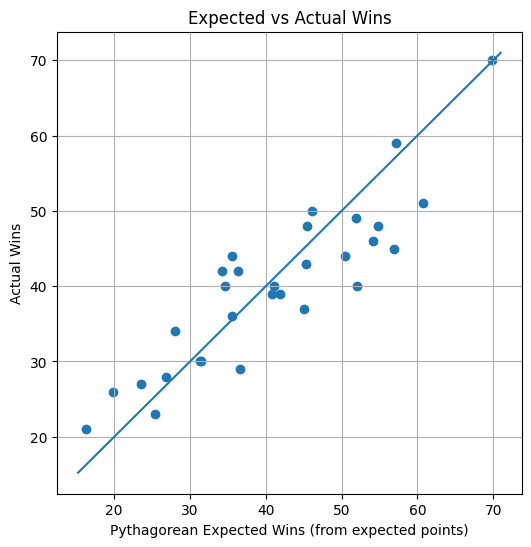

In [25]:

plt.figure(figsize=(6,6))
plt.scatter(season['pyth_wins_exp'], season['wins_actual'])
lims = [
    min(season['pyth_wins_exp'].min(), season['wins_actual'].min()) - 1,
    max(season['pyth_wins_exp'].max(), season['wins_actual'].max()) + 1
]
plt.plot(lims, lims)
plt.xlabel('Pythagorean Expected Wins (from expected points)')
plt.ylabel('Actual Wins')
plt.title('Expected vs Actual Wins')
plt.grid(True)
plt.show()


## 11.5) Player Performance vs Expected: Distribution Analysis

Total players: 576
Players with >=100 shots: 418

Percent Difference Summary (players with >=100 shots):
count    418.000000
mean      -0.181373
std        6.856004
min      -24.664160
25%       -3.923964
50%        0.057527
75%        4.125681
max       22.199500
Name: pct_diff, dtype: float64

Top 10 Overperformers (actual > expected):
playerName  total_shots  actual_points  exp_points  pct_diff
     Curry          343            411  336.335072 22.199500
Sensabaugh          599            707  607.089794 16.457210
    Battle          347            403  348.005593 15.802691
    Krejčí          278            366  316.515384 15.634141
     Green          121            151  131.014076 15.254675
  Williams          188            220  190.911007 15.236859
  Mitchell          184            205  177.900231 15.233042
      Post          274            319  277.782820 14.837862
    McCain          274            303  264.933667 14.368196
    Reeves          248            277  242.711823

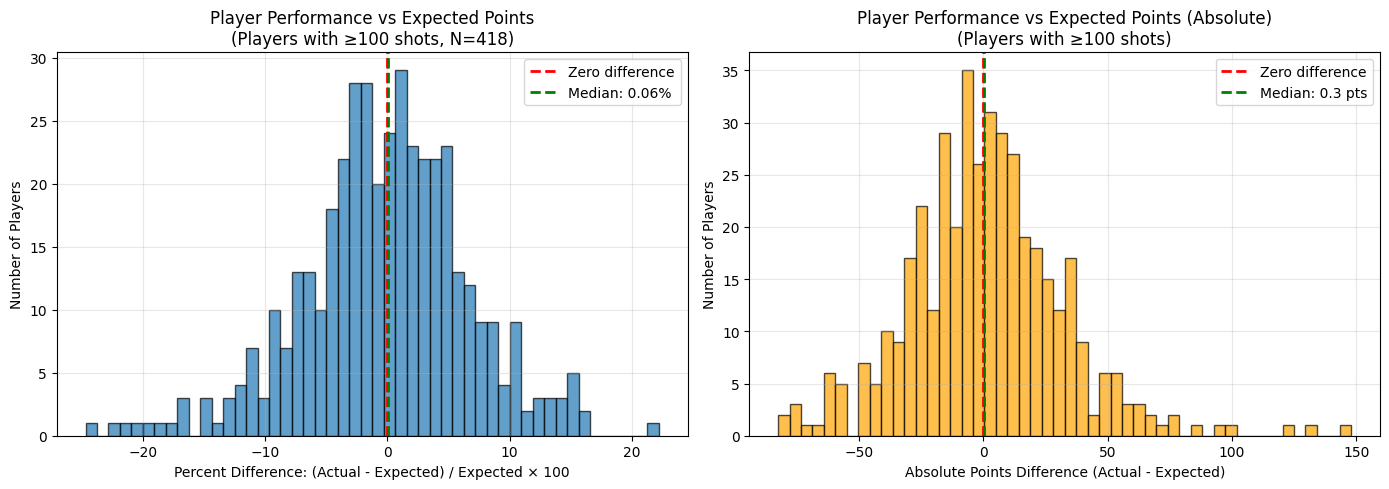


Saved: player_performance_vs_expected.csv (418 players)


In [26]:
# Player-level aggregation: actual vs expected points
if 'personId' not in df.columns or 'playerName' not in df.columns:
    print("Warning: personId or playerName not found in data. Skipping player analysis.")
else:
    player_stats = (df
        .groupby(['personId', 'playerName'], as_index=False)
        .agg(
            total_shots=('exp_points', 'size'),
            actual_points=('actual_points', 'sum'),
            exp_points=('exp_points', 'sum')
        )
    )
    
    # Calculate differences
    player_stats['points_diff'] = player_stats['actual_points'] - player_stats['exp_points']
    
    # Calculate percent difference: (actual - expected) / expected * 100
    # Add small epsilon to avoid division by zero
    player_stats['pct_diff'] = (
        (player_stats['actual_points'] - player_stats['exp_points']) / 
        (player_stats['exp_points'] + 0.001) * 100
    )
    
    # Filter to players with meaningful sample size (min 100 shots)
    min_shots = 100
    player_stats_filtered = player_stats[player_stats['total_shots'] >= min_shots].copy()
    
    print(f"Total players: {len(player_stats):,}")
    print(f"Players with >={min_shots} shots: {len(player_stats_filtered):,}")
    print(f"\nPercent Difference Summary (players with >={min_shots} shots):")
    print(player_stats_filtered['pct_diff'].describe())
    
    # Show top 10 overperformers and underperformers
    print(f"\nTop 10 Overperformers (actual > expected):")
    print(player_stats_filtered.nlargest(10, 'pct_diff')[
        ['playerName', 'total_shots', 'actual_points', 'exp_points', 'pct_diff']
    ].to_string(index=False))
    
    print(f"\nTop 10 Underperformers (actual < expected):")
    print(player_stats_filtered.nsmallest(10, 'pct_diff')[
        ['playerName', 'total_shots', 'actual_points', 'exp_points', 'pct_diff']
    ].to_string(index=False))
    
    # Create histogram of percent differences
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram 1: Percent difference distribution
    ax1.hist(player_stats_filtered['pct_diff'], bins=50, edgecolor='black', alpha=0.7)
    ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero difference')
    ax1.axvline(player_stats_filtered['pct_diff'].median(), color='green', 
                linestyle='--', linewidth=2, label=f'Median: {player_stats_filtered["pct_diff"].median():.2f}%')
    ax1.set_xlabel('Percent Difference: (Actual - Expected) / Expected × 100')
    ax1.set_ylabel('Number of Players')
    ax1.set_title(f'Player Performance vs Expected Points\n(Players with ≥{min_shots} shots, N={len(player_stats_filtered):,})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Histogram 2: Absolute points difference for context
    ax2.hist(player_stats_filtered['points_diff'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero difference')
    ax2.axvline(player_stats_filtered['points_diff'].median(), color='green', 
                linestyle='--', linewidth=2, label=f'Median: {player_stats_filtered["points_diff"].median():.1f} pts')
    ax2.set_xlabel('Absolute Points Difference (Actual - Expected)')
    ax2.set_ylabel('Number of Players')
    ax2.set_title(f'Player Performance vs Expected Points (Absolute)\n(Players with ≥{min_shots} shots)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Save player stats to CSV for further analysis
    player_stats_filtered_sorted = player_stats_filtered.sort_values('pct_diff', ascending=False)
    player_stats_filtered_sorted.to_csv('player_performance_vs_expected.csv', index=False)
    print(f"\nSaved: player_performance_vs_expected.csv ({len(player_stats_filtered_sorted):,} players)")

## 11.6) Key Visualizations for Paper

### 1) Calibration/Reliability Curve

Shows that predicted probabilities match actual make rates.

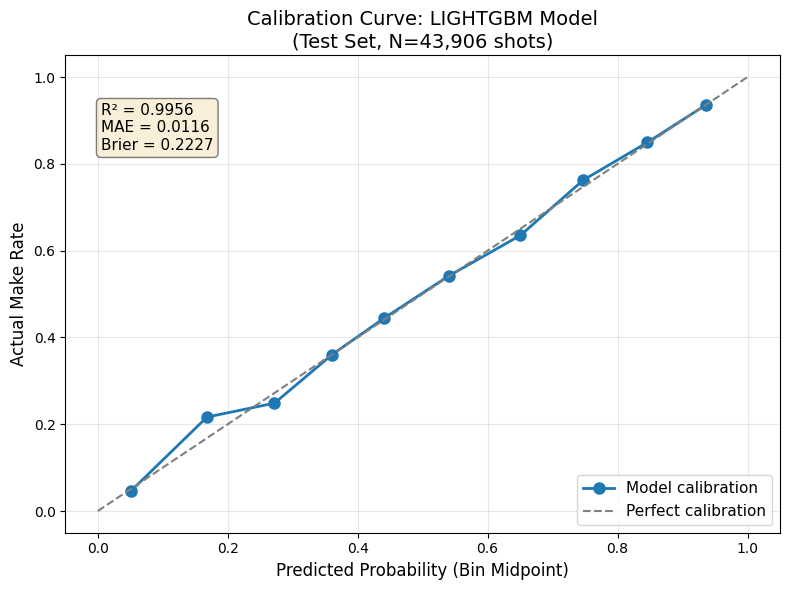


Calibration Metrics:
  R² (binned):       0.9956  (1.0 = perfect calibration)
  MAE (binned):      0.0116  (0.0 = perfect calibration)
  Brier Score:       0.2227  (0.0 = perfect calibration)

Calibration Curve Details:
Predicted Prob (Bin) | Actual Make Rate | Sample Size
------------------------------------------------------------
             0.052 |            0.047 | ~4,390
             0.168 |            0.216 | ~4,390
             0.272 |            0.249 | ~4,390
             0.361 |            0.361 | ~4,390
             0.440 |            0.444 | ~4,390
             0.540 |            0.542 | ~4,390
             0.651 |            0.635 | ~4,390
             0.747 |            0.763 | ~4,390
             0.846 |            0.849 | ~4,390
             0.937 |            0.937 | ~4,390


In [35]:
# Calibration curve for best model
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Get test set predictions
y_proba_test = best_model.predict_proba(X_test)[:,1]

# Create probability bins and calculate actual make rate in each bin
prob_true, prob_pred = calibration_curve(y_test, y_proba_test, n_bins=10, strategy='uniform')

# Quantitative calibration metrics
cal_r2 = 1 - np.sum((prob_true - prob_pred)**2) / np.sum((prob_true - np.mean(prob_true))**2)
cal_mae = np.mean(np.abs(prob_true - prob_pred))
brier = brier_score_loss(y_test, y_proba_test)

# Plot calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', markersize=8, linewidth=2, label='Model calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Predicted Probability (Bin Midpoint)', fontsize=12)
plt.ylabel('Actual Make Rate', fontsize=12)
plt.title(f'Calibration Curve: {best_name.upper()} Model\n(Test Set, N={len(y_test):,} shots)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

# Add metrics to plot
textstr = f'R\u00b2 = {cal_r2:.4f}\nMAE = {cal_mae:.4f}\nBrier = {brier:.4f}'
plt.text(0.05, 0.90, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print calibration statistics
print(f'\nCalibration Metrics:')
print(f'  R\u00b2 (binned):       {cal_r2:.4f}  (1.0 = perfect calibration)')
print(f'  MAE (binned):      {cal_mae:.4f}  (0.0 = perfect calibration)')
print(f'  Brier Score:       {brier:.4f}  (0.0 = perfect calibration)')
print(f'\nCalibration Curve Details:')
print('Predicted Prob (Bin) | Actual Make Rate | Sample Size')
print('-' * 60)
for i, (pred, actual) in enumerate(zip(prob_pred, prob_true)):
    bin_size = len(y_test) // 10
    print(f'{pred:18.3f} | {actual:16.3f} | ~{bin_size:,}')

### 2) League-Wide Shot Quality Heatmap

Half-court visualization showing average predicted make probability by location.

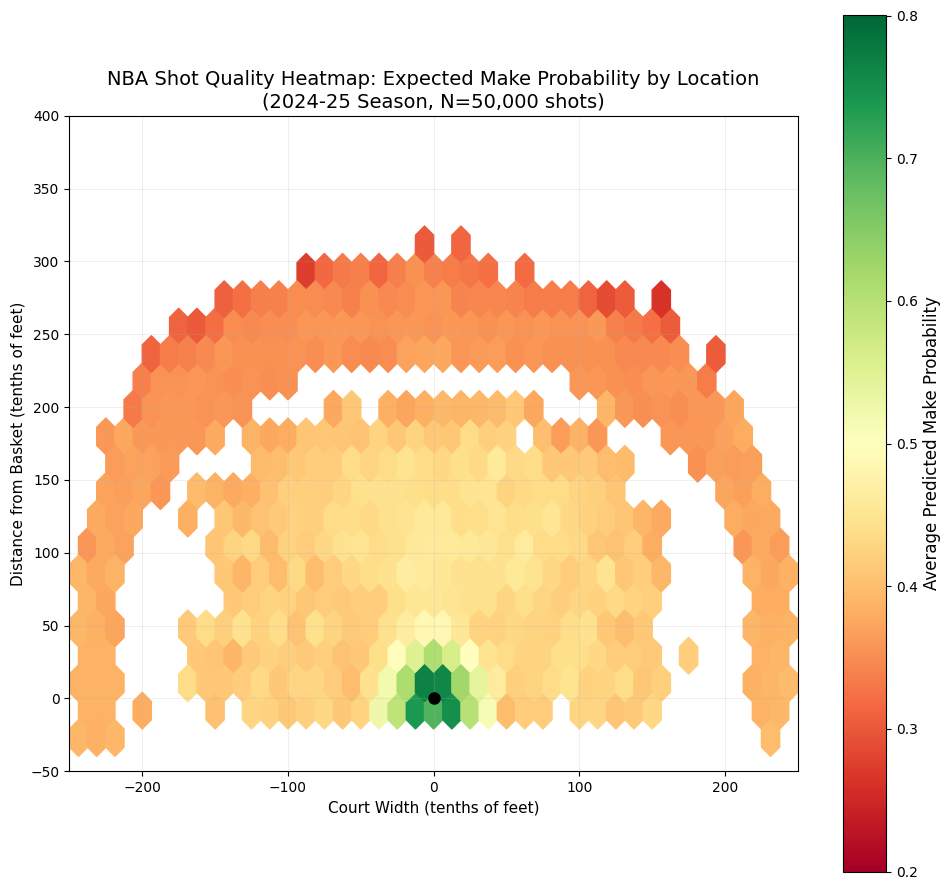


Heatmap shows average predicted make probability across 50,000 shots.
Green = high-quality shots (close to basket), Red = low-quality shots (deep/contested)


In [28]:
# League-wide shot quality heatmap
import matplotlib.patches as patches

# Check if we have coordinates
if 'xLegacy' not in df.columns or 'yLegacy' not in df.columns:
    print("Warning: xLegacy/yLegacy not found. Skipping heatmap.")
else:
    # Sample data for performance (use all shots if dataset is small)
    sample_size = min(50000, len(df))
    df_sample = df.sample(n=sample_size, random_state=42) if len(df) > sample_size else df
    
    # Create hexbin heatmap of predicted make probability
    fig, ax = plt.subplots(figsize=(10, 9))
    
    # Hexbin with average p_make as color
    hexbin = ax.hexbin(
        df_sample['xLegacy'], 
        df_sample['yLegacy'],
        C=df_sample['p_make'],  # Color by predicted probability
        gridsize=40,
        cmap='RdYlGn',  # Red (low) to Green (high)
        reduce_C_function=np.mean,  # Average probability per hex
        mincnt=10,  # Minimum shots per hex
        vmin=0.2,
        vmax=0.8
    )
    
    # Add basketball court elements
    # Basket at origin
    ax.plot([0], [0], 'ko', markersize=8, label='Basket')
    
    # Three-point line (simplified arc)
    from matplotlib.patches import Arc, Circle, Rectangle
    
    # # Paint/key (160 units wide, 190 units from basket)
    # paint = Rectangle((-80, 0), 160, 190, linewidth=2, edgecolor='black', facecolor='none')
    # ax.add_patch(paint)
    
    # # Free throw circle
    # ft_circle = Circle((0, 190), 60, linewidth=2, edgecolor='black', facecolor='none')
    # ax.add_patch(ft_circle)
    
    # # Three-point arc (237.5 units from basket, corners at 220 units from center)
    # three_arc = Arc((0, 0), 2*237.5, 2*237.5, angle=0, theta1=22, theta2=158, 
    #                 linewidth=2, edgecolor='black', facecolor='none')
    # ax.add_patch(three_arc)
    
    # # Corner threes
    # ax.plot([-220, -220], [0, 140], 'k-', linewidth=2)
    # ax.plot([220, 220], [0, 140], 'k-', linewidth=2)
    
    # Colorbar
    cbar = plt.colorbar(hexbin, ax=ax)
    cbar.set_label('Average Predicted Make Probability', fontsize=12)
    
    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 400)
    ax.set_aspect('equal')
    ax.set_xlabel('Court Width (tenths of feet)', fontsize=11)
    ax.set_ylabel('Distance from Basket (tenths of feet)', fontsize=11)
    ax.set_title(f'NBA Shot Quality Heatmap: Expected Make Probability by Location\n'
                 f'(2024-25 Season, N={sample_size:,} shots)', fontsize=14)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    print(f"\nHeatmap shows average predicted make probability across {sample_size:,} shots.")
    print("Green = high-quality shots (close to basket), Red = low-quality shots (deep/contested)")

### 3) Player "Luck" Distribution

Histogram of actual points minus expected points for all qualifying players.


Player Luck Analysis:
Total players with >=300 shots: 276

Luck Distribution Summary (Actual - Expected Points):
count    276.000000
mean       1.602131
std       36.655911
min      -82.641431
25%      -23.296147
50%        0.368786
75%       25.428329
max      147.978596
Name: points_diff, dtype: float64


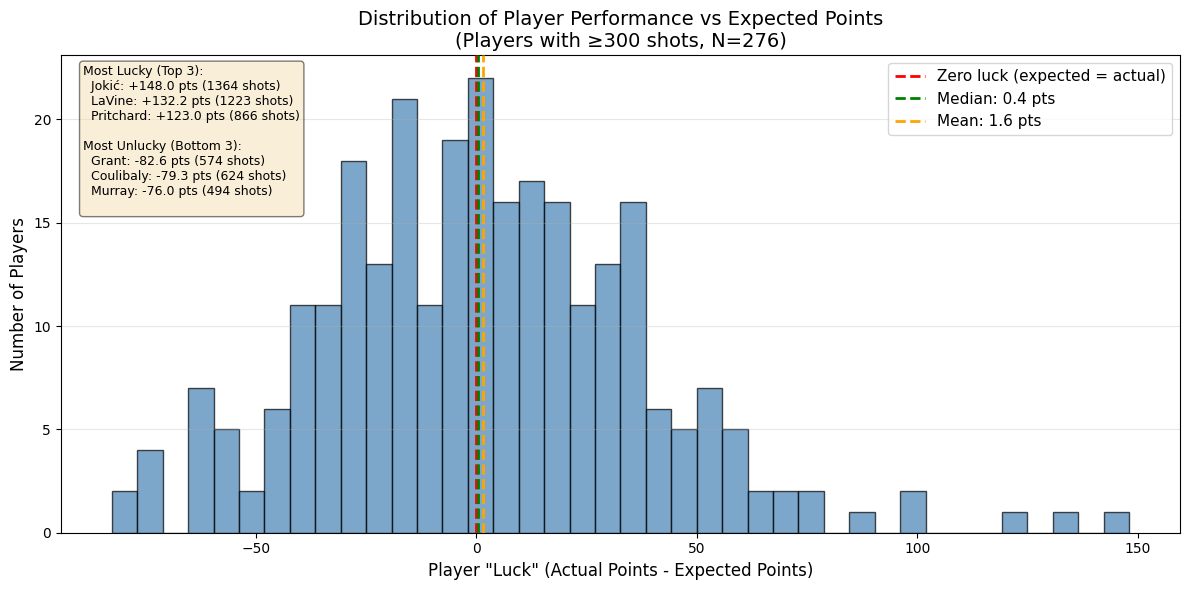


Standard Deviation: 36.66 points
Players within ±1 SD of mean: 197 (71.4%)

Interpretation: Most players cluster near 0, confirming model accurately predicts expected points.


In [29]:
# Player luck histogram
if 'personId' not in df.columns or 'playerName' not in df.columns:
    print("Warning: personId or playerName not found. Skipping player luck histogram.")
else:
    # Aggregate player stats (reuse if already computed)
    if 'player_stats' not in locals():
        player_stats = (df
            .groupby(['personId', 'playerName'], as_index=False)
            .agg(
                total_shots=('exp_points', 'size'),
                actual_points=('actual_points', 'sum'),
                exp_points=('exp_points', 'sum')
            )
        )
        player_stats['points_diff'] = player_stats['actual_points'] - player_stats['exp_points']
    
    # Filter to players with at least 300 shots
    min_shots_luck = 300
    player_stats_luck = player_stats[player_stats['total_shots'] >= min_shots_luck].copy()
    
    print(f"\nPlayer Luck Analysis:")
    print(f"Total players with >={min_shots_luck} shots: {len(player_stats_luck):,}")
    print(f"\nLuck Distribution Summary (Actual - Expected Points):")
    print(player_stats_luck['points_diff'].describe())
    
    # Create histogram
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Histogram
    n, bins, patches = ax.hist(
        player_stats_luck['points_diff'], 
        bins=40, 
        edgecolor='black', 
        alpha=0.7,
        color='steelblue'
    )
    
    # Add reference lines
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero luck (expected = actual)', zorder=5)
    ax.axvline(player_stats_luck['points_diff'].median(), color='green', linestyle='--', 
               linewidth=2, label=f'Median: {player_stats_luck["points_diff"].median():.1f} pts', zorder=5)
    ax.axvline(player_stats_luck['points_diff'].mean(), color='orange', linestyle='--', 
               linewidth=2, label=f'Mean: {player_stats_luck["points_diff"].mean():.1f} pts', zorder=5)
    
    # Labels
    ax.set_xlabel('Player "Luck" (Actual Points - Expected Points)', fontsize=12)
    ax.set_ylabel('Number of Players', fontsize=12)
    ax.set_title(f'Distribution of Player Performance vs Expected Points\n'
                 f'(Players with ≥{min_shots_luck} shots, N={len(player_stats_luck):,})', 
                 fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add text annotations for tails
    luckiest = player_stats_luck.nlargest(3, 'points_diff')[['playerName', 'points_diff', 'total_shots']]
    unluckiest = player_stats_luck.nsmallest(3, 'points_diff')[['playerName', 'points_diff', 'total_shots']]
    
    textstr = f"Most Lucky (Top 3):\n"
    for _, row in luckiest.iterrows():
        textstr += f"  {row['playerName']}: +{row['points_diff']:.1f} pts ({row['total_shots']} shots)\n"
    textstr += f"\nMost Unlucky (Bottom 3):\n"
    for _, row in unluckiest.iterrows():
        textstr += f"  {row['playerName']}: {row['points_diff']:.1f} pts ({row['total_shots']} shots)\n"
    
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print additional stats
    std_dev = player_stats_luck['points_diff'].std()
    print(f"\nStandard Deviation: {std_dev:.2f} points")
    print(f"Players within ±1 SD of mean: {((player_stats_luck['points_diff'] >= -std_dev) & (player_stats_luck['points_diff'] <= std_dev)).sum()} "
          f"({((player_stats_luck['points_diff'] >= -std_dev) & (player_stats_luck['points_diff'] <= std_dev)).sum() / len(player_stats_luck) * 100:.1f}%)")
    print(f"\nInterpretation: Most players cluster near 0, confirming model accurately predicts expected points.")


## 12) Save outputs (for your paper)
- `model_results.csv`: CV + test metrics per model
- `team_game_points.csv`: per-game expected & actual points (team-level)
- `season_standings.csv`: Pythagorean standings vs actual


In [30]:

results_df.to_csv('model_results.csv', index=False)
tg2.to_csv('team_game_points.csv', index=False)
standings.to_csv('season_standings.csv', index=False)
print('Saved: model_results.csv, team_game_points.csv, season_standings.csv')


Saved: model_results.csv, team_game_points.csv, season_standings.csv



## Appendix: Feature importances (trees/boosters & linear)


In [31]:

def feature_names_after_preprocess(preprocess, X):
    names = []
    # numeric original names
    if any(tr[0] == 'num' for tr in preprocess.transformers):
        names += list([*preprocess.transformers_[0][2]])
    # categorical OHE names
    try:
        cat_ix = [i for i,(nm,_,_) in enumerate(preprocess.transformers) if nm == 'cat'][0]
        ohe = preprocess.transformers_[cat_ix][1].named_steps['ohe']
        cat_cols = preprocess.transformers_[cat_ix][2]
        cat_names = ohe.get_feature_names_out(cat_cols)
        names += list(cat_names)
    except Exception:
        pass
    return names

try:
    clf = best_model.named_steps['clf']
    names = feature_names_after_preprocess(best_model.named_steps['preprocess'], X)

    if hasattr(clf, 'feature_importances_'):
        importances = pd.Series(clf.feature_importances_, index=names).sort_values(ascending=False).head(30)
        display(importances.to_frame('importance'))
    elif hasattr(clf, 'coef_'):
        coefs = pd.Series(np.ravel(clf.coef_), index=names)
        display(coefs.sort_values(key=np.abs, ascending=False).head(30).to_frame('coef'))
    else:
        print("Chosen model type does not expose standard importances/coefficients.")
except Exception as e:
    print("Could not compute feature importances:", e)


,importance
xLegacy,2705
prior_attempts,2690
yLegacy,2354
prior_fg_pct,2248
shot_angle_rad,2162
prior_fg2_pct,2015
ABS_TIME,1964
prior_fg3_pct,1922
period_sec_remaining,1826
period_sec_elapsed,1794


### Feature Importance Interpretation

#### Top Tier: Shot Location & Player History (7 features)
| Feature | Importance | Description |
|---------|------------|-------------|
| `xLegacy` | ~2705 | Court x-coordinate (left/right) |
| `yLegacy` | ~2354 | Court y-coordinate (baseline to half-court) |
| `shot_angle_rad` | ~2162 | Angle to basket from coordinates |
| `prior_attempts` | ~2690 | Player's prior season shot attempts |
| `prior_fg_pct` | ~2248 | Player's prior season FG% |
| `prior_fg2_pct` | ~2015 | Player's prior season 2PT% |
| `prior_fg3_pct` | ~1922 | Player's prior season 3PT% |

#### Second Tier: Game Context & Opponent Defense (11 features)
| Feature | Importance | Description |
|---------|------------|-------------|
| `ABS_TIME` | ~1964 | Absolute game time in seconds |
| `period` | - | Game period (1-4, OT) |
| `clock_x_distance` | ~1762 | Shot clock × distance interaction |
| `opp_def_3pt_pct` | ~1482 | Opponent's 3PT defense rating |
| `opp_def_mid_pct` | ~1372 | Opponent's mid-range defense rating |
| `opp_def_fg_pct` | ~958 | Opponent's overall FG% allowed |
| `opp_def_rim_pct` | ~1125 | Opponent's rim defense rating |
| `prior_shot_type_pct` | ~1245 | Prior FG% for this shot type (2PT/3PT) |
| `opp_def_shot_type_pct` | ~1132 | Opponent defense for shot type |
| `SHOT_CLOCK_APPROX` | ~1162 | Approximate shot clock |
| `shotDistance` | ~1083 | Distance from basket in feet |

#### Third Tier: Shot Characteristics (5 features)
| Feature | Importance | Description |
|---------|------------|-------------|
| `contest_score` | ~302 | Heuristic contest difficulty |
| `rhythm_x_distance` | ~495 | Rhythm shot × distance interaction |
| `shot_distance_log` | ~472 | Log-transformed distance |
| `clock_x_paint` | ~459 | Shot clock × paint shot interaction |
| `shotValue` | - | Point value (2 or 3) |

---

### Ablation Study Results

Comparing LightGBM performance across feature tiers:

| Configuration | Features | AUC | Log Loss | Accuracy |
|--------------|----------|-----|----------|----------|
| Top-Tier Only | 7 | 0.6407 | 0.6522 | 62.37% |
| Top + Second Tier | 7 + 11 = 18 | 0.6479 | 0.6482 | 62.45% |
| Full Model (All Tiers) | 7 + 11 + 5 = 23 | 0.6525 | 0.6453 | 62.90% |

**Note**: This ablation uses 23 features. The full model uses 77 features (AUC ~0.667).

---

### Key Insights

1. **Prior features are paying off**: Player history (`prior_fg_pct`, `prior_attempts`) and opponent defense (`opp_def_*`) add significant predictive power

2. **Location > Distance**: Court coordinates (`xLegacy`/`yLegacy`) are more important than raw `shotDistance`

3. **Interactions help**: `clock_x_distance` outperforms raw `SHOT_CLOCK_APPROX` alone

4. **Diminishing returns**: Adding tiers improves AUC, but gains decrease (Top→+Second: +0.007, +Third: +0.005)

---

## Ablation Study: Top-Tier Features Only

To quantify the contribution of each feature tier, we train LightGBM using only the top-tier features (shot location + player history) and compare against the full model.

In [32]:
# Ablation Study: Compare full model vs top-tier features only

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, accuracy_score

# Define feature tiers for ablation
TOP_TIER_NUMERIC = [
    'xLegacy', 'yLegacy', 'shot_angle_rad',
    'prior_attempts', 'prior_fg_pct', 'prior_fg2_pct', 'prior_fg3_pct',
]

SECOND_TIER_NUMERIC = [
    'ABS_TIME', 'period', 'clock_x_distance',
    'opp_def_3pt_pct', 'opp_def_mid_pct', 'opp_def_fg_pct', 'opp_def_rim_pct',
    'prior_shot_type_pct', 'opp_def_shot_type_pct',
    'SHOT_CLOCK_APPROX', 'shotDistance',
]

THIRD_TIER_NUMERIC = [
    'contest_score', 'rhythm_x_distance', 'shot_distance_log', 'clock_x_paint',
    'shotValue',
]

# Filter to features that exist in the data
def get_available_features(feature_list, df):
    return [f for f in feature_list if f in df.columns]

top_tier_available = get_available_features(TOP_TIER_NUMERIC, X_train)
second_tier_available = get_available_features(SECOND_TIER_NUMERIC, X_train)
third_tier_available = get_available_features(THIRD_TIER_NUMERIC, X_train)

print("=" * 70)
print("ABLATION STUDY: Feature Tier Contribution")
print("=" * 70)
print(f"\nTop-tier features available: {len(top_tier_available)}")
print(f"  {top_tier_available}")

# Build ablation configurations
ablation_configs = [
    ("Top-Tier Only", top_tier_available),
    ("Top + Second Tier", top_tier_available + second_tier_available),
    ("Full Model (All Tiers)", top_tier_available + second_tier_available + third_tier_available),
]

ablation_results = []

for config_name, feature_list in ablation_configs:
    print(f"\n{'-'*70}")
    print(f"Training: {config_name} ({len(feature_list)} features)")
    print(f"{'-'*70}")
    
    # Simple numeric-only preprocessor for ablation
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), feature_list)
        ],
        remainder='drop'
    )
    
    # Use same LightGBM params as best model
    ablation_model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.05,
            num_leaves=64,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=1.0,
            reg_lambda=1.0,
            min_child_samples=20,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])
    
    # Train and evaluate
    ablation_model.fit(X_train, y_train)
    y_pred_proba = ablation_model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)
    brier = brier_score_loss(y_test, y_pred_proba)
    
    # Find best threshold
    best_thresh, best_acc = 0.5, accuracy_score(y_test, (y_pred_proba >= 0.5).astype(int))
    for t in np.arange(0.4, 0.6, 0.01):
        acc = accuracy_score(y_test, (y_pred_proba >= t).astype(int))
        if acc > best_acc:
            best_acc, best_thresh = acc, t
    
    print(f"  AUC:      {auc:.4f}")
    print(f"  Log Loss: {logloss:.4f}")
    print(f"  Accuracy: {best_acc*100:.2f}% (threshold={best_thresh:.2f})")
    
    ablation_results.append({
        'config': config_name,
        'n_features': len(feature_list),
        'auc': auc,
        'log_loss': logloss,
        'brier': brier,
        'accuracy': best_acc,
    })

# Summary table
print("\n" + "=" * 70)
print("ABLATION STUDY SUMMARY")
print("=" * 70)
ablation_df = pd.DataFrame(ablation_results)
print(ablation_df.to_string(index=False))

# Calculate contribution of each tier
if len(ablation_results) >= 2:
    top_only_auc = ablation_results[0]['auc']
    full_auc = ablation_results[-1]['auc']
    auc_gain = full_auc - top_only_auc
    
    print(f"\n{'='*70}")
    print("KEY FINDING:")
    print(f"{'='*70}")
    print(f"  Top-tier features alone: AUC = {top_only_auc:.4f}")
    print(f"  Full model:              AUC = {full_auc:.4f}")
    print(f"  AUC gain from 2nd/3rd tier features: +{auc_gain:.4f} ({auc_gain/top_only_auc*100:.1f}% relative improvement)")
    print(f"\nConclusion: {'Second/third tier features provide meaningful lift.' if auc_gain > 0.005 else 'Top-tier features capture most of the signal.'}")

ABLATION STUDY: Feature Tier Contribution

Top-tier features available: 7
  ['xLegacy', 'yLegacy', 'shot_angle_rad', 'prior_attempts', 'prior_fg_pct', 'prior_fg2_pct', 'prior_fg3_pct']

----------------------------------------------------------------------
Training: Top-Tier Only (7 features)
----------------------------------------------------------------------
  AUC:      0.6407
  Log Loss: 0.6522
  Accuracy: 62.37% (threshold=0.52)

----------------------------------------------------------------------
Training: Top + Second Tier (18 features)
----------------------------------------------------------------------
  AUC:      0.6479
  Log Loss: 0.6482
  Accuracy: 62.45% (threshold=0.50)

----------------------------------------------------------------------
Training: Full Model (All Tiers) (23 features)
----------------------------------------------------------------------
  AUC:      0.6525
  Log Loss: 0.6453
  Accuracy: 62.90% (threshold=0.50)

ABLATION STUDY SUMMARY
              


## Appendix: Calibration curve (test set)


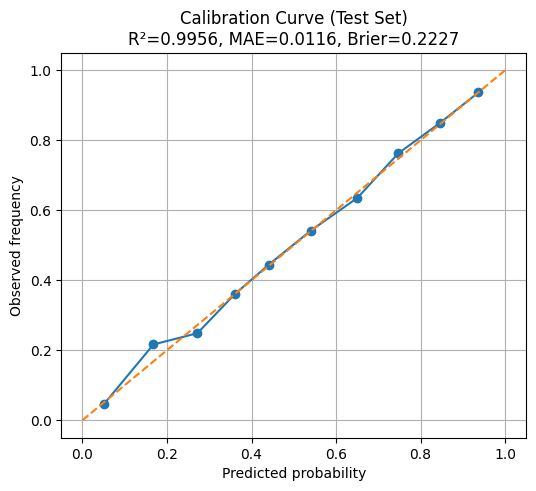

In [36]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

y_proba = best_model.predict_proba(X_test)[:,1]
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')

# Quantitative calibration metrics
cal_r2 = 1 - np.sum((prob_true - prob_pred)**2) / np.sum((prob_true - np.mean(prob_true))**2)
cal_mae = np.mean(np.abs(prob_true - prob_pred))
brier = brier_score_loss(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title(f'Calibration Curve (Test Set)\nR\u00b2={cal_r2:.4f}, MAE={cal_mae:.4f}, Brier={brier:.4f}')
plt.grid(True)
plt.show()

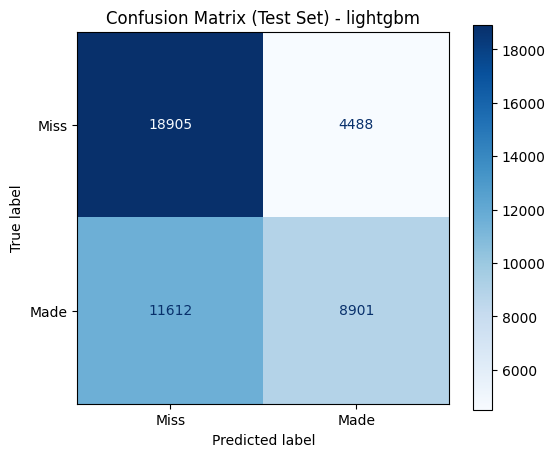


Confusion Matrix Breakdown (Test Set):
True Negatives (Correct Misses):  18,905
False Positives (Predicted Made, Actually Missed): 4,488
False Negatives (Predicted Miss, Actually Made): 11,612
True Positives (Correct Makes):   8,901

Total Test Samples: 43,906
Accuracy: 63.33%


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for test set
y_pred_test = (best_model.predict_proba(X_test)[:,1] >= best_threshold).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Miss', 'Made'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (Test Set) - {best_name}')
plt.grid(False)
plt.show()

# Print detailed metrics
print(f"\nConfusion Matrix Breakdown (Test Set):")
print(f"True Negatives (Correct Misses):  {cm[0,0]:,}")
print(f"False Positives (Predicted Made, Actually Missed): {cm[0,1]:,}")
print(f"False Negatives (Predicted Miss, Actually Made): {cm[1,0]:,}")
print(f"True Positives (Correct Makes):   {cm[1,1]:,}")
print(f"\nTotal Test Samples: {cm.sum():,}")
print(f"Accuracy: {(cm[0,0] + cm[1,1]) / cm.sum() * 100:.2f}%")
